In [1]:
# CELL 01 — Setup

#import necessary libraries for data analytics 
import pandas as pd
import numpy as np
import re
import unicodedata
from pathlib import Path

#expand the display options to show all columns and rows
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

#define file paths for input and output data 
DATA_PATH = Path("Acled_Stat250.xlsx")
OUTPUT_PATH = Path("Acled_Stat250_cleaned_event_level.xlsx")

# ---------------------------------------------------------
# Project plot color theme
# ---------------------------------------------------------

# ---------------------------------------------------------
# Project plot color theme
# ---------------------------------------------------------

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

PRIMARY = "#1F4E79"       # main blue: general event patterns
SECONDARY = "#9ECAE1"     # light blue: background/all events
ACCENT = "#A23B3B"        # muted red: fatalities/severity
ACCENT_LIGHT = "#D98C8C"  # light red
NEUTRAL = "#BFBFBF"       # gray
DARK = "#333333"

EVENT_TYPE_COLORS = {
    "Protests": PRIMARY,
    "Strategic developments": SECONDARY,
    "Battles": ACCENT,
    "Explosions/Remote violence": ACCENT_LIGHT,
    "Violence against civilians": "#7A1F1F",
    "Riots": "#6C8EBF"
}

PROJECT_CMAP = LinearSegmentedColormap.from_list(
    "project_cmap",
    [ACCENT, "white", PRIMARY]
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": DARK,
    "axes.labelcolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "text.color": DARK,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False
})

In [2]:
# CELL 02 — Load Raw Data

#load the raw data from Excel and create a copy for cleaning
df_raw = pd.read_excel(DATA_PATH)
df = df_raw.copy()

#strip whitespace from column names
df.columns = df.columns.str.strip()

#print basic information about the raw data
print("=== RAW DATA ===")
print(f"Raw shape: {df_raw.shape}")

print("\nFirst rows:")
display(df.head(5))

print("\nColumn names:")
print(df.columns.tolist())

=== RAW DATA ===
Raw shape: (32447, 31)

First rows:


,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,interaction,civilian_targeting,iso,region,country,admin1,admin2,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp,population_1km,population_2km,population_5km,population_best
0,TUR1914,2016-01-01,2016,1,Political Violence,Battles,Armed Clash,Pkk: Kurdistan Workers Party,NaN,1,12,NaN,792,Middle East,Turkey,Sirnak,Cizre,Cizre,373274,421785,1,Cihan News Agency,National,"On 1 January 2016, Three Pkk Militants Were Ki...",4.0,NaN,1.650491e+09,23473.0,73955.0,84980.0,84980.0
1,TUR1914,2016-01-01,2016,1,Political Violence,Battles,Armed Clash,Military Forces Of Turkey (2002-2016),NaN,1,12,NaN,792,Middle East,Turkey,Sirnak,Cizre,Cizre,373274,421785,1,Cihan News Agency,National,"On 1 January 2016, Three Pkk Militants Were Ki...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TUR1915,2016-01-01,2016,1,Political Violence,Battles,Armed Clash,Military Forces Of Turkey (2002-2016),NaN,1,12,NaN,792,Middle East,Turkey,Sirnak,Silopi,Silopi,372438,424634,1,Cihan News Agency,National,"On 1 January 2016, Five Pkk Militants Were Kil...",5.0,NaN,1.650491e+09,25624.0,77114.0,98175.0,98175.0
3,TUR1915,2016-01-01,2016,1,Political Violence,Battles,Armed Clash,Pkk: Kurdistan Workers Party,NaN,1,12,NaN,792,Middle East,Turkey,Sirnak,Silopi,Silopi,372438,424634,1,Cihan News Agency,National,"On 1 January 2016, Five Pkk Militants Were Kil...",5.0,NaN,1.650491e+09,25624.0,77114.0,98175.0,98175.0
4,TUR1916,2016-01-01,2016,1,Political Violence,Battles,Armed Clash,Military Forces Of Turkey (2002-2016) Gendarmerie,NaN,1,12,NaN,792,Middle East,Turkey,Diyarbakir,Sur,Sur,379109,402366,1,Beyaz Gazete,National,"On 1 January 2016, İn Fatih Pasa Neighborhood ...",0.0,NaN,1.705380e+09,24960.0,35439.0,43250.0,43250.0



Column names:
['event_id_cnty', 'event_date', 'year', 'time_precision', 'disorder_type', 'event_type', 'sub_event_type', 'actor1', 'assoc_actor_1', 'inter1', 'interaction', 'civilian_targeting', 'iso', 'region', 'country', 'admin1', 'admin2', 'location', 'latitude', 'longitude', 'geo_precision', 'source', 'source_scale', 'notes', 'fatalities', 'tags', 'timestamp', 'population_1km', 'population_2km', 'population_5km', 'population_best']


In [3]:
# CELL 03 — Helper Functions

# helper function to standardize text by cleaning spaces and accents
def normalize_key(value):
    if pd.isna(value):
        return pd.NA
    
    value = str(value).strip()
    value = unicodedata.normalize("NFKD", value)
    value = "".join(ch for ch in value if not unicodedata.combining(ch))
    value = re.sub(r"\s+", " ", value)
    return value.lower()

# helper function to map messy category labels to standard labels using a provided mapping
def canonicalize_series(series, mapping):
    keys = series.map(normalize_key)
    mapped = keys.map(mapping)
    return mapped.fillna(series.astype("string").str.strip())

# helper function to add a source name to the source column without duplicating it
def add_source(existing_source, new_source):
    # Add a source name to the source column without duplicating it.
    if pd.isna(new_source) or str(new_source).strip() == "":
        return existing_source
    
    new_source = str(new_source).strip()
    
    if pd.isna(existing_source) or str(existing_source).strip() == "":
        return new_source
    
    existing_parts = [
        part.strip()
        for part in str(existing_source).split(";")
        if part.strip()
    ]
    
    if new_source not in existing_parts:
        existing_parts.append(new_source)
    
    return "; ".join(existing_parts)


print("[CHECK] Helper functions are ready.")

[CHECK] Helper functions are ready.


In [4]:
# CELL 04 — Audit: Basic Structure and Missing Values

print("=== BASIC STRUCTURE AUDIT ===")

#print the number of rows and columns in the dataset
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Define the columns that are likely to be used for data cleaning and statistical analysis
audit_cols = [
    "event_id_cnty", "event_date", "year", "timestamp",
    "time_precision", "geo_precision",
    "disorder_type", "event_type", "sub_event_type",
    "actor1", "actor2", "assoc_actor_1", "assoc_actor_2",
    "civilian_targeting",
    "country", "region", "admin1", "admin2", "location",
    "latitude", "longitude",
    "source", "source_scale",
    "fatalities",
    "population_1km", "population_2km", "population_5km", "population_best",
    "notes", "tags"
]
#keep only the columns that are present in the dataset to avoid errors
audit_cols = [col for col in audit_cols if col in df.columns]

#print the number of missing values in the selected columns
print("\nMissing values in selected columns:")
missing_selected = df[audit_cols].isna().sum().to_frame("missing_count")
display(missing_selected)

#filter, sort, and display columns with at least one missing value
print("\nColumns with at least one missing value:")
missing_all = df.isna().sum()
missing_all = missing_all[missing_all > 0].sort_values(ascending=False).to_frame("missing_count")
display(missing_all)

=== BASIC STRUCTURE AUDIT ===
Rows: 32447
Columns: 31

Missing values in selected columns:


,missing_count
event_id_cnty,0
event_date,0
year,0
timestamp,117
time_precision,0
geo_precision,0
disorder_type,0
event_type,0
sub_event_type,0
actor1,0



Columns with at least one missing value:


,missing_count
civilian_targeting,30465
tags,20382
assoc_actor_1,18950
population_best,8091
population_5km,721
population_2km,349
population_1km,189
timestamp,117
fatalities,28
notes,14


In [5]:
# CELL 05 — Audit: Event ID and Coordinates

print("=== EVENT ID AND COORDINATE AUDIT ===")

# 1.) Event ID format check
#cast the event_id_cnty column to string and strip whitespace for accurate format checking
event_id_raw = df["event_id_cnty"].astype("string").str.strip()

# define the expected format for event_id_cnty as three uppercase letters followed by digits (e.g., TUR1914)
valid_event_id_mask = event_id_raw.str.match(r"^[A-Z]{3}\d+$", na=False)

#count and display rows that do not match the expected event_id_cnty format
print("\n1. Event ID format check:")
print(f"Rows with unexpected event_id_cnty format: {(~valid_event_id_mask).sum()}")

display(
    df.loc[
        ~valid_event_id_mask,
        ["event_id_cnty"]
    ]
    .drop_duplicates()
    .head(10)
)


# 2.) Coordinate range check
print("\n2. Coordinate check:")
#convert latitude and longitude to numeric to detect scale errors and invalid entries
lat_numeric = pd.to_numeric(df["latitude"], errors="coerce")
lon_numeric = pd.to_numeric(df["longitude"], errors="coerce")

#print summary statistics for spatial coordinates
coordinate_summary = pd.DataFrame({
    "latitude": lat_numeric.describe(),
    "longitude": lon_numeric.describe()
})
display(coordinate_summary)

#identify rows where latitude and longitude are outside valid global ranges
invalid_coordinate_mask = (
    lat_numeric.notna()
    & lon_numeric.notna()
    & (
        (lat_numeric < -90) | (lat_numeric > 90)
        | (lon_numeric < -180) | (lon_numeric > 180)
    )
)
print(f"Rows with coordinates outside valid global ranges: {invalid_coordinate_mask.sum()}")
display(
    df.loc[
        invalid_coordinate_mask,
        ["event_id_cnty", "latitude", "longitude"]
    ].head(10)
)

=== EVENT ID AND COORDINATE AUDIT ===

1. Event ID format check:
Rows with unexpected event_id_cnty format: 7603


,event_id_cnty
16,_x000D_TUR1923
17,_x000D_TUR1928
44,_x000D_TUR1939
53,_x000D_TUR1946
54,_x000D_TUR1947
99,_x000D_TUR1968
100,_x000D_TUR5354
109,_x000D_TUR1975
124,_x000D_TUR1981
179,_x000D_TUR34611



2. Coordinate check:


,latitude,longitude
count,32447.000000,32447.000000
mean,389129.153173,356928.629118
std,14726.460934,61151.884581
min,358585.000000,259090.000000
25%,375736.000000,290521.000000
50%,385080.000000,354922.000000
75%,400333.000000,414848.000000
max,420386.000000,446961.000000


Rows with coordinates outside valid global ranges: 32447


,event_id_cnty,latitude,longitude
0,TUR1914,373274,421785
1,TUR1914,373274,421785
2,TUR1915,372438,424634
3,TUR1915,372438,424634
4,TUR1916,379109,402366
5,TUR1916,379109,402366
6,TUR1917,373274,421785
7,TUR1917,373274,421785
8,TUR1918,379109,402366
9,TUR1918,379109,402366


In [6]:
# CELL 06 — Audit: Categories

print("=== CATEGORY AUDIT ===")

#define the official ACLED event_type, disorder_type, and sub_event_type for validation 
official_event_types = {
    "Battles",
    "Protests",
    "Riots",
    "Explosions/Remote violence",
    "Violence against civilians",
    "Strategic developments"
}

official_disorder_types = {
    "Political violence",
    "Demonstrations",
    "Strategic developments",
    "Political violence; Demonstrations"
}

official_sub_event_types = {
    "Government regains territory",
    "Non-state actor overtakes territory",
    "Armed clash",
    "Excessive force against protesters",
    "Protest with intervention",
    "Peaceful protest",
    "Violent demonstration",
    "Mob violence",
    "Chemical weapon",
    "Air/drone strike",
    "Suicide bomb",
    "Shelling/artillery/missile attack",
    "Remote explosive/landmine/IED",
    "Grenade",
    "Sexual violence",
    "Attack",
    "Abduction/forced disappearance",
    "Agreement",
    "Arrests",
    "Change to group/activity",
    "Disrupted weapons use",
    "Headquarters or base established",
    "Looting/property destruction",
    "Non-violent transfer of territory",
    "Other"
}

#standardize the category values for comparison using text normalization
official_event_keys = {normalize_key(x) for x in official_event_types}
official_disorder_keys = {normalize_key(x) for x in official_disorder_types}
official_sub_event_keys = {normalize_key(x) for x in official_sub_event_types}

#normalize the category values for comparison
event_type_keys = df["event_type"].map(normalize_key)
disorder_type_keys = df["disorder_type"].map(normalize_key)
sub_event_type_keys = df["sub_event_type"].map(normalize_key)

#create masks to identify rows where the category values do not match the official lists
unexpected_event_mask = ~event_type_keys.isin(official_event_keys)
unexpected_disorder_mask = ~disorder_type_keys.isin(official_disorder_keys)
unexpected_sub_event_mask = ~sub_event_type_keys.isin(official_sub_event_keys)

unexpected_category_mask = (
    unexpected_event_mask
    | unexpected_disorder_mask
    | unexpected_sub_event_mask
)

#extract and sort the unique unexpected category values for review
unexpected_event_types = sorted(
    df.loc[unexpected_event_mask, "event_type"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

unexpected_disorder_types = sorted(
    df.loc[unexpected_disorder_mask, "disorder_type"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

unexpected_sub_event_types = sorted(
    df.loc[unexpected_sub_event_mask, "sub_event_type"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

#print the unexpected category values and example rows
print("\nUnexpected event_type values:")
print(unexpected_event_types)

print("\nUnexpected disorder_type values:")
print(unexpected_disorder_types)

print("\nUnexpected sub_event_type values:")
print(unexpected_sub_event_types)

print("\nRows with unexpected category values:")

#show the rows with incorrect categories
display(
    df.loc[
        unexpected_category_mask,
        [
            "event_id_cnty",
            "event_type",
            "sub_event_type",
            "disorder_type",
            "actor1",
            "assoc_actor_1"
        ]
    ].head(20)
)

=== CATEGORY AUDIT ===

Unexpected event_type values:
['Demonstrations']

Unexpected disorder_type values:
[]

Unexpected sub_event_type values:
['Protests']

Rows with unexpected category values:


,event_id_cnty,event_type,sub_event_type,disorder_type,actor1,assoc_actor_1
10860,_x000D_TUR7871,Demonstrations,Protests,Political Violence,Excessive Force Against Protesters,"Protesters (Turkey), Ihd: Human Rights Associa..."
13937,_x000D_TUR9815,Demonstrations,Protests,Political Violence,Excessive Force Against Protesters,"Protesters (Turkey), Hdp: Peoples Democratic P..."


In [7]:
# CELL 07 — Audit: Source Scale and Duplicates

print("=== SOURCE SCALE AND DUPLICATE AUDIT ===")

#define the set of allowed source scale parts based on ACLED documentation 
allowed_source_scale_parts = {
    "Local partner",
    "Local",
    "Subnational",
    "National",
    "Regional",
    "International",
    "New media",
    "Other"
}

#function to check if the source_scale value is valid based on allowed parts
def source_scale_is_valid(value):
    if pd.isna(value):
        return False
    
    parts = [part.strip() for part in str(value).split("-")]
    return all(part in allowed_source_scale_parts for part in parts)

#clean and strip spaces from source_scale values 
source_scale_values = (
    df["source_scale"]
    .astype("string")
    .str.strip()
)

#identify rows with non-standard source_scale values and display the number of such rows 
invalid_source_scale_mask = ~source_scale_values.map(source_scale_is_valid)
print("\n1. Source scale format check:")
print(f"Rows with unexpected source_scale format: {invalid_source_scale_mask.sum()}")

display(
    df.loc[
        invalid_source_scale_mask,
        ["event_id_cnty", "source", "source_scale"]
    ]
    .drop_duplicates()
    .head(15)
)

#display the most common source_scale values to check for common patterns and potential errors
print("\n2. Most common source_scale values:")
display(
    source_scale_values
    .value_counts(dropna=False)
    .head(20)
    .to_frame("count")
)

#check for exact duplicate rows in the dataset before cleaning 
print("\n3. Exact duplicate row check:")
print(f"Exact duplicate rows before cleaning: {df.duplicated().sum()}")

=== SOURCE SCALE AND DUPLICATE AUDIT ===

1. Source scale format check:
Rows with unexpected source_scale format: 163


,event_id_cnty,source,source_scale
71,TUR1951,Liveuamap,Local Partner-New Media
83,TUR1957,Liveuamap,Local Partner-New Media
298,TUR3140,Liveuamap; Twitter,Local Partner-New Media
335,TUR3164,Ap; Liveuamap; Twitter,Local Partner-New Media
497,TUR3252,Liveuamap,Local Partner-New Media
508,TUR3249,Liveuamap,Local Partner-New Media
671,TUR3317,Hurriyet Daily; Liveuamap,Local Partner-New Media
867,TUR3387,Twitter; Liveuamap,Local Partner-New Media
1009,TUR3455,Liveuamap; Twitter,Local Partner-New Media
1059,TUR3480,Hurriyet Daily; Twitter; Liveuamap; Beyaz Gazete,Local Partner-New Media



2. Most common source_scale values:


,count
source_scale,
National,16232
Other,6360
International,5225
National-International,1591
Other-National,1412
National-Regional,416
Other-International,388
Subnational,348
Local Partner-New Media,116



3. Exact duplicate row check:
Exact duplicate rows before cleaning: 58


In [8]:
# CELL 08 — Basic Technical Cleaning

print("=== BASIC TECHNICAL CLEANING ===")

#extract clean ID's by removing unrecoverable leading characters 
df["event_id_cnty"] = (
    df["event_id_cnty"]
    .astype(str)
    .str.strip()
    .str.extract(r"([A-Z]{3}\d+)", expand=False)
)

#drop rows where the event ID cannot be secured
rows_before_id_drop = df.shape[0]
df = df.dropna(subset=["event_id_cnty"]).copy()
print(f"Rows dropped due to unrecoverable event_id_cnty: {rows_before_id_drop - df.shape[0]}")

#convert event date to true datetime format
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")

#turn numerical columns into numeric data types
numeric_cols = [
    "year", "timestamp",
    "time_precision", "geo_precision",
    "inter1", "interaction", "iso",
    "fatalities",
    "population_1km", "population_2km", "population_5km", "population_best",
    "latitude", "longitude"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

#correct coordinate scales by dividing by 10000
for col in ["latitude", "longitude"]:
    if col in df.columns and df[col].abs().median() > 1000:
        df[col] = df[col] / 10000

#clean extra whitespaces in text columns.
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].map(
        lambda x: re.sub(r"\s+", " ", x.strip()) if isinstance(x, str) else x
    )

#print summary information after cleaning
print("\nBasic technical cleaning complete.")
print(f"Shape after basic technical cleaning: {df.shape}")
print(f"Unique event IDs after ID cleaning: {df['event_id_cnty'].nunique()}")

print("\nEvent ID check after cleaning:")
event_id_check = df["event_id_cnty"].astype("string").str.match(r"^[A-Z]{3}\d+$", na=False)
print(f"Rows with unexpected event_id_cnty format: {(~event_id_check).sum()}")

print("\nCoordinate check after cleaning:")
display(df[["latitude", "longitude"]].describe())

preview_cols = [
    "event_id_cnty", "event_date", "year",
    "latitude", "longitude", "fatalities",
    "event_type", "sub_event_type", "source", "source_scale"
]

preview_cols = [col for col in preview_cols if col in df.columns]

#show a preview of the cleaned data with key columns 
display(df[preview_cols].head(10))

=== BASIC TECHNICAL CLEANING ===
Rows dropped due to unrecoverable event_id_cnty: 0


C:\Users\hasan\AppData\Local\Temp\ipykernel_3688\592601068.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns



Basic technical cleaning complete.
Shape after basic technical cleaning: (32447, 31)
Unique event IDs after ID cleaning: 22118

Event ID check after cleaning:
Rows with unexpected event_id_cnty format: 0

Coordinate check after cleaning:


,latitude,longitude
count,32447.000000,32447.000000
mean,38.912915,35.692863
std,1.472646,6.115188
min,35.858500,25.909000
25%,37.573600,29.052100
50%,38.508000,35.492200
75%,40.033300,41.484800
max,42.038600,44.696100


,event_id_cnty,event_date,year,latitude,longitude,fatalities,event_type,sub_event_type,source,source_scale
0,TUR1914,2016-01-01,2016,37.3274,42.1785,4.0,Battles,Armed Clash,Cihan News Agency,National
1,TUR1914,2016-01-01,2016,37.3274,42.1785,NaN,Battles,Armed Clash,Cihan News Agency,National
2,TUR1915,2016-01-01,2016,37.2438,42.4634,5.0,Battles,Armed Clash,Cihan News Agency,National
3,TUR1915,2016-01-01,2016,37.2438,42.4634,5.0,Battles,Armed Clash,Cihan News Agency,National
4,TUR1916,2016-01-01,2016,37.9109,40.2366,0.0,Battles,Armed Clash,Beyaz Gazete,National
5,TUR1916,2016-01-01,2016,37.9109,40.2366,0.0,Battles,Armed Clash,Beyaz Gazete,National
6,TUR1917,2016-01-01,2016,37.3274,42.1785,1.0,Explosions/Remote violence,Shelling/Artillery/Missile Attack,Anadolu Agency,National
7,TUR1917,2016-01-01,2016,37.3274,42.1785,1.0,Explosions/Remote violence,Shelling/Artillery/Missile Attack,Anadolu Agency,National
8,TUR1918,2016-01-01,2016,37.9109,40.2366,2.0,Explosions/Remote violence,Remote Explosive/Landmine/Ied,Bianet,National
9,TUR1918,2016-01-01,2016,37.9109,40.2366,2.0,Explosions/Remote violence,Remote Explosive/Landmine/Ied,Bianet,National


In [9]:
# CELL 09 — Targeted Corrections Based on Audit

print("=== TARGETED FIXES BASED ON AUDIT ===")

# 1.) Clean source_scale values

#standard mapping to normalize messy source_scale values 
source_scale_part_map = {
    "local partner": "Local partner",
    "local": "Local",
    "subnational": "Subnational",
    "national": "National",
    "regional": "Regional",
    "international": "International",
    "new media": "New media",
    "other": "Other"
}

allowed_scale_keys = set(source_scale_part_map.keys())

#function to clean source_scale values and fix cases where the source name is mixed with the scale
def clean_source_scale_and_source(row):
    source = row["source"]
    scale = row["source_scale"]
    
    if pd.isna(scale):
        return pd.Series([source, scale])
    
    scale_text = str(scale).strip()
    
    # CASE 1: standardize hyphen-separated scale values (e.g., "Local Partner-New Media")
    if "-" in scale_text:
        parts = [part.strip() for part in scale_text.split("-")]
        cleaned_parts = []
        
        for part in parts:
            key = normalize_key(part)
            cleaned_parts.append(source_scale_part_map.get(key, part))
        
        return pd.Series([source, "-".join(cleaned_parts)])
    
    # CASE 2: Fix a source name mixed with the scale (e.g., "Evrensel National")
    tokens = scale_text.split()
    
    if len(tokens) >= 2:
        possible_scale = tokens[-1]
        possible_source = " ".join(tokens[:-1])
        scale_key = normalize_key(possible_scale)
        
        if scale_key in allowed_scale_keys:
            corrected_source = add_source(source, possible_source)
            corrected_scale = source_scale_part_map[scale_key]
            return pd.Series([corrected_source, corrected_scale])
    
    # CASE 3: fix capitalization or spacing errors in single scale strings (e.g., "national" to "National")
    scale_key = normalize_key(scale_text)
    
    if scale_key in allowed_scale_keys:
        return pd.Series([source, source_scale_part_map[scale_key]])
    
    return pd.Series([source, scale_text])


source_scale_before = df["source_scale"].copy()

#apply the cleaning function to all rows
df[["source", "source_scale"]] = df.apply(
    clean_source_scale_and_source,
    axis=1
)

source_scale_changed = (source_scale_before.astype("string") != df["source_scale"].astype("string")).sum()

print(f"Rows with source_scale changed: {source_scale_changed}")

#display the most common source_scale values after cleaning to verify normalization 
print("\nSource scale values after targeted source-scale cleaning:")
display(
    df["source_scale"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False)
    .head(20)
    .to_frame("count")
)

# 2.) Fix shifted protest rows

# in these rows, "Excessive Force Against Protesters" appears under actor1, but it should be the sub_event_type.
shifted_protest_mask = (
    df["event_type"].map(normalize_key).eq("demonstrations")
    & df["sub_event_type"].map(normalize_key).eq("protests")
    & df["actor1"].map(normalize_key).eq("excessive force against protesters")
)

shifted_protest_ids = df.loc[shifted_protest_mask, "event_id_cnty"].tolist()

print(f"\nShifted protest rows corrected: {shifted_protest_mask.sum()}")

#relocate shifted column values to their correct columns
for idx in df[shifted_protest_mask].index:
    assoc_value = df.loc[idx, "assoc_actor_1"]
    
    if pd.notna(assoc_value):
        parts = [p.strip() for p in re.split(r";|,", str(assoc_value)) if p.strip()]
    else:
        parts = []
    
    #re-assign the correct values to event_type, sub_event_type, disorder_type, and actors
    df.loc[idx, "event_type"] = "Protests"
    df.loc[idx, "sub_event_type"] = "Excessive force against protesters"
    df.loc[idx, "disorder_type"] = "Political violence; Demonstrations"
    
    #extract the main actor from assoc_actor_1 and move it to actor1, and keep any additional actors in assoc_actor_1
    if len(parts) > 0:
        df.loc[idx, "actor1"] = parts[0]
        df.loc[idx, "assoc_actor_1"] = "; ".join(parts[1:]) if len(parts) > 1 else pd.NA

#print the corrected rows to verify the changes
if len(shifted_protest_ids) > 0:
    print("\nCorrected shifted protest rows:")
    display(
        df.loc[
            df["event_id_cnty"].isin(shifted_protest_ids),
            [
                "event_id_cnty",
                "event_type",
                "sub_event_type",
                "disorder_type",
                "actor1",
                "assoc_actor_1"
            ]
        ]
    )

=== TARGETED FIXES BASED ON AUDIT ===
Rows with source_scale changed: 157

Source scale values after targeted source-scale cleaning:


,count
source_scale,
National,16234
Other,6360
International,5225
National-International,1591
Other-National,1413
National-Regional,416
Other-International,388
Subnational,348
Local partner-New media,116



Shifted protest rows corrected: 2

Corrected shifted protest rows:


,event_id_cnty,event_type,sub_event_type,disorder_type,actor1,assoc_actor_1
10860,TUR7871,Protests,Excessive force against protesters,Political violence; Demonstrations,Protesters (Turkey),Ihd: Human Rights Association; Tıhv: Human Rig...
10861,TUR7871,Protests,Excessive Force Against Protesters,Political Violence; Demonstrations,Police Forces Of Turkey (2016-),NaN
13937,TUR9815,Protests,Excessive force against protesters,Political violence; Demonstrations,Protesters (Turkey),Hdp: Peoples Democratic Party; Government Of T...
13948,TUR9815,Protests,Excessive Force Against Protesters,Political Violence; Demonstrations,Police Forces Of Turkey (2016-),NaN


In [10]:
# CELL 10 — Category Standardization and Duplicate Removal

print("=== CATEGORY STANDARDIZATION AND DUPLICATE REMOVAL ===")

#define reference dictionaries to standardize category names based on the official ACLED categories
EVENT_TYPE_MAP = {
    "battles": "Battles",
    "protests": "Protests",
    "riots": "Riots",
    "explosions/remote violence": "Explosions/Remote violence",
    "violence against civilians": "Violence against civilians",
    "strategic developments": "Strategic developments",
    "demonstrations": "Protests"
}

DISORDER_TYPE_MAP = {
    "political violence": "Political violence",
    "demonstrations": "Demonstrations",
    "strategic developments": "Strategic developments",
    "political violence; demonstrations": "Political violence; Demonstrations"
}

SUB_EVENT_TYPE_MAP = {
    "government regains territory": "Government regains territory",
    "non-state actor overtakes territory": "Non-state actor overtakes territory",
    "armed clash": "Armed clash",
    "excessive force against protesters": "Excessive force against protesters",
    "protest with intervention": "Protest with intervention",
    "peaceful protest": "Peaceful protest",
    "violent demonstration": "Violent demonstration",
    "mob violence": "Mob violence",
    "chemical weapon": "Chemical weapon",
    "air/drone strike": "Air/drone strike",
    "suicide bomb": "Suicide bomb",
    "shelling/artillery/missile attack": "Shelling/artillery/missile attack",
    "remote explosive/landmine/ied": "Remote explosive/landmine/IED",
    "grenade": "Grenade",
    "sexual violence": "Sexual violence",
    "attack": "Attack",
    "abduction/forced disappearance": "Abduction/forced disappearance",
    "agreement": "Agreement",
    "arrests": "Arrests",
    "change to group/activity": "Change to group/activity",
    "disrupted weapons use": "Disrupted weapons use",
    "headquarters or base established": "Headquarters or base established",
    "looting/property destruction": "Looting/property destruction",
    "non-violent transfer of territory": "Non-violent transfer of territory",
    "other": "Other"
}

#standardize and normalize all category columns
df["event_type"] = canonicalize_series(df["event_type"], EVENT_TYPE_MAP)
df["disorder_type"] = canonicalize_series(df["disorder_type"], DISORDER_TYPE_MAP)
df["sub_event_type"] = canonicalize_series(df["sub_event_type"], SUB_EVENT_TYPE_MAP)

#count and remove exact duplicate rows after cleaning.
exact_duplicates_after_cleaning = df.duplicated().sum()
df = df.drop_duplicates().copy()

print(f"Exact duplicate rows removed after cleaning: {exact_duplicates_after_cleaning}")
print(f"Shape after duplicate removal: {df.shape}")
print(f"Unique event IDs after duplicate removal: {df['event_id_cnty'].nunique()}")

#validate categories against the official ACLED categories to identify any remaining unexpected values 
official_event_types = set(EVENT_TYPE_MAP.values())
official_disorder_types = set(DISORDER_TYPE_MAP.values())
official_sub_event_types = set(SUB_EVENT_TYPE_MAP.values())

unexpected_event_types = sorted(set(df["event_type"].dropna().unique()) - official_event_types)
unexpected_disorder_types = sorted(set(df["disorder_type"].dropna().unique()) - official_disorder_types)
unexpected_sub_event_types = sorted(set(df["sub_event_type"].dropna().unique()) - official_sub_event_types)

print("\nUnexpected category values after standardization:")
print(f"event_type: {unexpected_event_types}")
print(f"disorder_type: {unexpected_disorder_types}")
print(f"sub_event_type: {unexpected_sub_event_types}")

#display the category counts after cleaning to verify the standardization 
print("\nEvent type counts after cleaning:")
display(df["event_type"].value_counts(dropna=False).to_frame("count"))

print("\nSub-event type counts after cleaning:")
display(df["sub_event_type"].value_counts(dropna=False).to_frame("count"))

preview_cols = [
    "event_id_cnty", "event_date", "year",
    "event_type", "sub_event_type", "disorder_type",
    "actor1", "source", "source_scale",
    "latitude", "longitude", "fatalities"
]

preview_cols = [col for col in preview_cols if col in df.columns]

#show a preview of the cleaned dataset
display(df[preview_cols].head(10))

=== CATEGORY STANDARDIZATION AND DUPLICATE REMOVAL ===
Exact duplicate rows removed after cleaning: 64
Shape after duplicate removal: (32383, 31)
Unique event IDs after duplicate removal: 22118

Unexpected category values after standardization:
event_type: []
disorder_type: []
sub_event_type: []

Event type counts after cleaning:


,count
event_type,
Protests,14730
Strategic developments,7681
Battles,5776
Explosions/Remote violence,2353
Violence against civilians,1336
Riots,507



Sub-event type counts after cleaning:


,count
sub_event_type,
Peaceful protest,10848
Armed clash,5776
Looting/property destruction,3910
Protest with intervention,3852
Arrests,2342
Attack,1290
Remote explosive/landmine/IED,947
Air/drone strike,737
Change to group/activity,682


,event_id_cnty,event_date,year,event_type,sub_event_type,disorder_type,actor1,source,source_scale,latitude,longitude,fatalities
0,TUR1914,2016-01-01,2016,Battles,Armed clash,Political violence,Pkk: Kurdistan Workers Party,Cihan News Agency,National,37.3274,42.1785,4.0
1,TUR1914,2016-01-01,2016,Battles,Armed clash,Political violence,Military Forces Of Turkey (2002-2016),Cihan News Agency,National,37.3274,42.1785,NaN
2,TUR1915,2016-01-01,2016,Battles,Armed clash,Political violence,Military Forces Of Turkey (2002-2016),Cihan News Agency,National,37.2438,42.4634,5.0
3,TUR1915,2016-01-01,2016,Battles,Armed clash,Political violence,Pkk: Kurdistan Workers Party,Cihan News Agency,National,37.2438,42.4634,5.0
4,TUR1916,2016-01-01,2016,Battles,Armed clash,Political violence,Military Forces Of Turkey (2002-2016) Gendarmerie,Beyaz Gazete,National,37.9109,40.2366,0.0
5,TUR1916,2016-01-01,2016,Battles,Armed clash,Political violence,Pkk: Kurdistan Workers Party,Beyaz Gazete,National,37.9109,40.2366,0.0
6,TUR1917,2016-01-01,2016,Explosions/Remote violence,Shelling/artillery/missile attack,Political violence,Military Forces Of Turkey (2002-2016),Anadolu Agency,National,37.3274,42.1785,1.0
7,TUR1917,2016-01-01,2016,Explosions/Remote violence,Shelling/artillery/missile attack,Political violence,Pkk: Kurdistan Workers Party,Anadolu Agency,National,37.3274,42.1785,1.0
8,TUR1918,2016-01-01,2016,Explosions/Remote violence,Remote explosive/landmine/IED,Political violence,Pkk: Kurdistan Workers Party,Bianet,National,37.9109,40.2366,2.0
9,TUR1918,2016-01-01,2016,Explosions/Remote violence,Remote explosive/landmine/IED,Political violence,Police Forces Of Turkey (2002-2016),Bianet,National,37.9109,40.2366,2.0


In [11]:
# CELL 11 — Event-Level Aggregation

print("=== EVENT-LEVEL AGGREGATION ===")

#function to return the first non-missing value within an event group for aggregation
def first_non_missing(series):
    non_missing = series.dropna()
    return non_missing.iloc[0] if len(non_missing) > 0 else pd.NA

#function to collect unique values from a series, splitting by specified separators if needed, while preserving original order
def collect_unique_values(series, separators=None):
    values = []

    for value in series.dropna():
        value = str(value).strip()

        if value == "" or value.lower() == "nan":
            continue

        if separators is None:
            parts = [value]
        else:
            parts = [p.strip() for p in re.split(separators, value) if p.strip()]

        for part in parts:
            if part and part.lower() != "nan" and part not in values:
                values.append(part)

    return values

#function to expand flattened lists into numbered separate columns (e.g., actor1, actor2)
#also creates a count column to indicate how many items were in the original list for each event
def expand_list_series(list_series, prefix):
    max_count = int(list_series.map(len).max()) if len(list_series) > 0 else 0

    expanded = pd.DataFrame(index=list_series.index)

    for i in range(max_count):
        expanded[f"{prefix}{i + 1}"] = list_series.map(
            lambda values: values[i] if i < len(values) else pd.NA
        )

    count_name = f"{prefix.rstrip('_')}_count"
    expanded[count_name] = list_series.map(len)

    return expanded, max_count

#group by event_id_cnty to aggregate rows that belong to the same event.
grouped = df.groupby("event_id_cnty", sort=False)


#select core event columns to keep, making sure they actually exist in our dataset
core_columns = [
    "event_date", "year", "timestamp",
    "time_precision", "geo_precision",
    "disorder_type", "event_type", "sub_event_type",
    "inter1", "interaction", "civilian_targeting",
    "iso", "region", "country", "admin1", "admin2", "location",
    "latitude", "longitude",
    "source_scale",
    "population_1km", "population_2km", "population_5km", "population_best",
    "notes", "tags"
]

core_columns = [col for col in core_columns if col in df.columns]

#aggregate core event-level variables by taking the first non-missing value
df_final = grouped[core_columns].agg(first_non_missing).reset_index()

#Fatalities are event-level reported counts. If repeated rows differ, keep the maximum reported value.
fatalities_by_event = grouped["fatalities"].max().reset_index()
df_final = df_final.merge(fatalities_by_event, on="event_id_cnty", how="left")

#gather all unique primary actors for each event and split them into separate wide columns
actor_lists = grouped["actor1"].apply(lambda s: collect_unique_values(s, separators=None))
actor_expanded, max_actor_count = expand_list_series(actor_lists, "actor")
df_final = df_final.merge(actor_expanded.reset_index(), on="event_id_cnty", how="left")

#gather, de-duplicate, and split all associated actors using semicolons or commas as separators
assoc_lists = grouped["assoc_actor_1"].apply(lambda s: collect_unique_values(s, separators=r";|,"))
assoc_expanded, max_assoc_actor_count = expand_list_series(assoc_lists, "assoc_actor_")
df_final = df_final.merge(assoc_expanded.reset_index(), on="event_id_cnty", how="left")

#gather and de-duplicate all media sources reported for each event using semicolons
source_lists = grouped["source"].apply(lambda s: collect_unique_values(s, separators=r";"))
source_expanded, max_source_count = expand_list_series(source_lists, "source")
df_final = df_final.merge(source_expanded.reset_index(), on="event_id_cnty", how="left")

# Drop completely empty columns, if any.
df_final = df_final.dropna(axis=1, how="all")

#print summary information about the final aggregated dataset
print("[CHECK] Aggregation complete.")
print(f"Rows before aggregation: {df.shape[0]}")
print(f"Unique event IDs before aggregation: {df['event_id_cnty'].nunique()}")
print(f"Event-level rows: {df_final.shape[0]}")
print(f"Duplicate event IDs after aggregation: {df_final['event_id_cnty'].duplicated().sum()}")

print("\nMaximum observed counts:")
print(f"Max actor count: {max_actor_count}")
print(f"Max associated actor count: {max_assoc_actor_count}")
print(f"Max source count: {max_source_count}")

#select key columns for previewing the final dataset
preview_cols = [
    "event_id_cnty", "event_date", "year",
    "event_type", "sub_event_type", "fatalities",
    "actor1", "actor2", "actor_count",
    "assoc_actor_1", "assoc_actor_2", "assoc_actor_count",
    "source1", "source2", "source_count"
]

preview_cols = [col for col in preview_cols if col in df_final.columns]

#show a preview of the final aggregated event-level dataset
display(df_final[preview_cols].head(10))

=== EVENT-LEVEL AGGREGATION ===
[CHECK] Aggregation complete.
Rows before aggregation: 32383
Unique event IDs before aggregation: 22118
Event-level rows: 22118
Duplicate event IDs after aggregation: 0

Maximum observed counts:
Max actor count: 2
Max associated actor count: 23
Max source count: 9


,event_id_cnty,event_date,year,event_type,sub_event_type,fatalities,actor1,actor2,actor_count,assoc_actor_1,assoc_actor_2,assoc_actor_count,source1,source2,source_count
0,TUR1914,2016-01-01,2016,Battles,Armed clash,4.0,Pkk: Kurdistan Workers Party,Military Forces Of Turkey (2002-2016),2,NaN,NaN,0,Cihan News Agency,NaN,1
1,TUR1915,2016-01-01,2016,Battles,Armed clash,5.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,NaN,NaN,0,Cihan News Agency,NaN,1
2,TUR1916,2016-01-01,2016,Battles,Armed clash,0.0,Military Forces Of Turkey (2002-2016) Gendarmerie,Pkk: Kurdistan Workers Party,2,NaN,NaN,0,Beyaz Gazete,NaN,1
3,TUR1917,2016-01-01,2016,Explosions/Remote violence,Shelling/artillery/missile attack,1.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,NaN,NaN,0,Anadolu Agency,NaN,1
4,TUR1918,2016-01-01,2016,Explosions/Remote violence,Remote explosive/landmine/IED,2.0,Pkk: Kurdistan Workers Party,Police Forces Of Turkey (2002-2016),2,Military Forces Of Turkey (2002-2016),NaN,1,Bianet,NaN,1
5,TUR1919,2016-01-01,2016,Riots,Mob violence,0.0,Civilians (Turkey),Rioters (Turkey),2,Pkk: Kurdistan Workers Party,NaN,1,Today'S Zaman,NaN,1
6,TUR1920,2016-01-01,2016,Violence against civilians,Attack,1.0,Civilians (Turkey),Military Forces Of Turkey (2002-2016),2,NaN,NaN,0,Bianet,NaN,1
7,TUR34792,2016-01-01,2016,Battles,Armed clash,1.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,NaN,NaN,0,People'S Defense Forces,NaN,1
8,TUR1923,2016-01-02,2016,Battles,Armed clash,2.0,Unidentified Armed Group (Turkey),Police Forces Of Turkey (2002-2016),2,NaN,NaN,0,Kurdish Globe,NaN,1
9,TUR1928,2016-01-02,2016,Protests,Protest with intervention,0.0,Protesters (Turkey),Police Forces Of Turkey (2002-2016),2,NaN,NaN,0,Kurdish Globe,NaN,1


In [12]:
# CELL 12 — Reorder Columns for Final Output

print("=== REORDERING COLUMNS ===")

#function to identify and return columns in correct numeric order (e.g., actor1, actor2)
def numbered_columns(dataframe, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}(\d+)$")
    
    cols = []
    
    for col in dataframe.columns:
        match = pattern.match(col)
        
        if match:
            cols.append((int(match.group(1)), col))
    
    return [col for _, col in sorted(cols)]

#group and sort the dynamic columns for actors, associated actors, and sources
actor_cols = numbered_columns(df_final, "actor")
assoc_actor_cols = numbered_columns(df_final, "assoc_actor_")
source_cols = numbered_columns(df_final, "source")

count_cols = [
    col for col in ["actor_count", "assoc_actor_count", "source_count"]
    if col in df_final.columns
]

dynamic_cols = set(actor_cols + assoc_actor_cols + source_cols + count_cols)

#define a preferred order for the core event-level columns, ensuring they exist in the dataset
preferred_first_cols = [
    "event_id_cnty", "event_date", "year", "timestamp",
    "time_precision", "geo_precision",
    "disorder_type", "event_type", "sub_event_type",
    "inter1", "interaction", "civilian_targeting",
    "fatalities",
    "country", "region", "admin1", "admin2", "location",
    "latitude", "longitude",
    "source_scale",
    "population_1km", "population_2km", "population_5km", "population_best",
    "tags", "notes"
]

preferred_first_cols = [col for col in preferred_first_cols if col in df_final.columns]

#place the preferred core columns first, followed by the dynamic actor and source columns, and then any remaining columns
remaining_cols = [
    col for col in df_final.columns
    if col not in preferred_first_cols and col not in dynamic_cols
]

#define the final column order for the output dataset
final_order = (
    preferred_first_cols
    + actor_cols
    + (["actor_count"] if "actor_count" in df_final.columns else [])
    + assoc_actor_cols
    + (["assoc_actor_count"] if "assoc_actor_count" in df_final.columns else [])
    + source_cols
    + (["source_count"] if "source_count" in df_final.columns else [])
    + remaining_cols
)

#reorder the columns in the final dataset according to the defined order
df_final = df_final[final_order].copy()

print(f"Final shape after reordering: {df_final.shape}")

print("\nActor columns:")
print(actor_cols)

print("\nAssociated actor columns:")
print(assoc_actor_cols)

print("\nSource columns:")
print(source_cols)

#show a preview of the final dataset with the new column order
preview_cols = [
    "event_id_cnty", "event_date", "year",
    "event_type", "sub_event_type", "fatalities",
    "actor1", "actor2", "actor_count",
    "source1", "source2", "source_count"
]

preview_cols = [col for col in preview_cols if col in df_final.columns]

display(df_final[preview_cols].head(10))

=== REORDERING COLUMNS ===
Final shape after reordering: (22118, 65)

Actor columns:
['actor1', 'actor2']

Associated actor columns:
['assoc_actor_1', 'assoc_actor_2', 'assoc_actor_3', 'assoc_actor_4', 'assoc_actor_5', 'assoc_actor_6', 'assoc_actor_7', 'assoc_actor_8', 'assoc_actor_9', 'assoc_actor_10', 'assoc_actor_11', 'assoc_actor_12', 'assoc_actor_13', 'assoc_actor_14', 'assoc_actor_15', 'assoc_actor_16', 'assoc_actor_17', 'assoc_actor_18', 'assoc_actor_19', 'assoc_actor_20', 'assoc_actor_21', 'assoc_actor_22', 'assoc_actor_23']

Source columns:
['source1', 'source2', 'source3', 'source4', 'source5', 'source6', 'source7', 'source8', 'source9']


,event_id_cnty,event_date,year,event_type,sub_event_type,fatalities,actor1,actor2,actor_count,source1,source2,source_count
0,TUR1914,2016-01-01,2016,Battles,Armed clash,4.0,Pkk: Kurdistan Workers Party,Military Forces Of Turkey (2002-2016),2,Cihan News Agency,NaN,1
1,TUR1915,2016-01-01,2016,Battles,Armed clash,5.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,Cihan News Agency,NaN,1
2,TUR1916,2016-01-01,2016,Battles,Armed clash,0.0,Military Forces Of Turkey (2002-2016) Gendarmerie,Pkk: Kurdistan Workers Party,2,Beyaz Gazete,NaN,1
3,TUR1917,2016-01-01,2016,Explosions/Remote violence,Shelling/artillery/missile attack,1.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,Anadolu Agency,NaN,1
4,TUR1918,2016-01-01,2016,Explosions/Remote violence,Remote explosive/landmine/IED,2.0,Pkk: Kurdistan Workers Party,Police Forces Of Turkey (2002-2016),2,Bianet,NaN,1
5,TUR1919,2016-01-01,2016,Riots,Mob violence,0.0,Civilians (Turkey),Rioters (Turkey),2,Today'S Zaman,NaN,1
6,TUR1920,2016-01-01,2016,Violence against civilians,Attack,1.0,Civilians (Turkey),Military Forces Of Turkey (2002-2016),2,Bianet,NaN,1
7,TUR34792,2016-01-01,2016,Battles,Armed clash,1.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,People'S Defense Forces,NaN,1
8,TUR1923,2016-01-02,2016,Battles,Armed clash,2.0,Unidentified Armed Group (Turkey),Police Forces Of Turkey (2002-2016),2,Kurdish Globe,NaN,1
9,TUR1928,2016-01-02,2016,Protests,Protest with intervention,0.0,Protesters (Turkey),Police Forces Of Turkey (2002-2016),2,Kurdish Globe,NaN,1


In [13]:
# CELL 13 — Quality Checks for Final Dataset

print("=== QUALITY CHECKS FOR FINAL EVENT-LEVEL DATASET ===")

# 1. Dataset shape
print("\n1. Dataset shape:")
print(f"Rows: {df_final.shape[0]}")
print(f"Columns: {df_final.shape[1]}")

# 2. Category counts
print("\n2. Event type counts:")
display(df_final["event_type"].value_counts(dropna=False).to_frame("count"))

print("\n3. Disorder type counts:")
display(df_final["disorder_type"].value_counts(dropna=False).to_frame("count"))

print("\n4. Sub-event type counts:")
display(df_final["sub_event_type"].value_counts(dropna=False).to_frame("count"))

# 3. Category validation using the official reference lists
print("\n5. Category validation:")

official_event_types = {
    "Battles",
    "Protests",
    "Riots",
    "Explosions/Remote violence",
    "Violence against civilians",
    "Strategic developments"
}

official_disorder_types = {
    "Political violence",
    "Demonstrations",
    "Strategic developments",
    "Political violence; Demonstrations"
}

official_sub_event_types = {
    "Government regains territory",
    "Non-state actor overtakes territory",
    "Armed clash",
    "Excessive force against protesters",
    "Protest with intervention",
    "Peaceful protest",
    "Violent demonstration",
    "Mob violence",
    "Chemical weapon",
    "Air/drone strike",
    "Suicide bomb",
    "Shelling/artillery/missile attack",
    "Remote explosive/landmine/IED",
    "Grenade",
    "Sexual violence",
    "Attack",
    "Abduction/forced disappearance",
    "Agreement",
    "Arrests",
    "Change to group/activity",
    "Disrupted weapons use",
    "Headquarters or base established",
    "Looting/property destruction",
    "Non-violent transfer of territory",
    "Other"
}

#cross-reference with official lists to catch remaining errors
unexpected_event_types = sorted(set(df_final["event_type"].dropna().unique()) - official_event_types)
unexpected_disorder_types = sorted(set(df_final["disorder_type"].dropna().unique()) - official_disorder_types)
unexpected_sub_event_types = sorted(set(df_final["sub_event_type"].dropna().unique()) - official_sub_event_types)

print(f"Unexpected event_type values: {unexpected_event_types}")
print(f"Unexpected disorder_type values: {unexpected_disorder_types}")
print(f"Unexpected sub_event_type values: {unexpected_sub_event_types}")

# 4. Country check
print("\n6. Country check:")
display(df_final["country"].value_counts(dropna=False).to_frame("count"))

# 5. Coordinate range check
print("\n7. Coordinate range check:")
display(df_final[["latitude", "longitude"]].describe())

#ensure all coordinates are within valid global ranges
invalid_coordinate_mask = (
    df_final["latitude"].notna()
    & df_final["longitude"].notna()
    & (
        (df_final["latitude"] < -90) | (df_final["latitude"] > 90)
        | (df_final["longitude"] < -180) | (df_final["longitude"] > 180)
    )
)

print(f"Rows with invalid coordinate ranges: {invalid_coordinate_mask.sum()}")

# 6. Precision metrics check
print("\n8. Time precision counts:")
display(df_final["time_precision"].value_counts(dropna=False).sort_index().to_frame("count"))

print("\n9. Geo precision counts:")
display(df_final["geo_precision"].value_counts(dropna=False).sort_index().to_frame("count"))

# 7.Dynamic column counts check
print("\n10. Actor count check:")
display(df_final["actor_count"].value_counts(dropna=False).sort_index().to_frame("count"))

print("\n11. Associated actor count check:")
display(df_final["assoc_actor_count"].value_counts(dropna=False).sort_index().to_frame("count"))

print("\n12. Source count check:")
display(df_final["source_count"].value_counts(dropna=False).sort_index().to_frame("count"))

# 8. Fatalities check
print("\n13. Fatalities check:")
display(df_final["fatalities"].describe().to_frame("fatalities"))
print(f"Negative fatalities: {(df_final['fatalities'] < 0).sum()}")

# 9. Date and year consistency check
print("\n14. Date/year consistency check:")

df_final["event_date"] = pd.to_datetime(df_final["event_date"], errors="coerce")
df_final["year"] = pd.to_numeric(df_final["year"], errors="coerce")

#check for mismatches between the year extracted from event_date and the year column
year_mismatch = (df_final["event_date"].dt.year != df_final["year"]).sum()

print(f"Year mismatches: {year_mismatch}")
print(f"Earliest event date: {df_final['event_date'].min()}")
print(f"Latest event date: {df_final['event_date'].max()}")

# 10. Missing value scan for the final dataset 
print("\n15. Missing value audit:")
missing = df_final.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

display(missing.to_frame("missing_count"))

=== QUALITY CHECKS FOR FINAL EVENT-LEVEL DATASET ===

1. Dataset shape:
Rows: 22118
Columns: 65

2. Event type counts:


,count
event_type,
Protests,12785
Strategic developments,4203
Battles,2894
Explosions/Remote violence,1294
Violence against civilians,668
Riots,274



3. Disorder type counts:


,count
disorder_type,
Demonstrations,12843
Political violence,5058
Strategic developments,4203
Political violence; Demonstrations,14



4. Sub-event type counts:


...

,count
source_count,
1,17245
2,3373
3,1043
4,386
5,59
6,10
7,1
9,1



13. Fatalities check:


,fatalities
count,22100.000000
mean,0.323529
std,1.900302
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,104.000000


Negative fatalities: 0

14. Date/year consistency check:
Year mismatches: 0
Earliest event date: 2016-01-01 00:00:00
Latest event date: 2024-01-01 00:00:00

15. Missing value audit:


,missing_count
source9,22117
source8,22117
assoc_actor_22,22117
assoc_actor_23,22117
assoc_actor_19,22116
assoc_actor_21,22116
assoc_actor_20,22116
source7,22116
assoc_actor_18,22115
assoc_actor_17,22114


In [14]:
# CELL 14 — Final Cleaning Decisions

print("=== FINAL CLEANING DECISIONS AFTER QUALITY CHECK ===")

# 1. Fill missing fatalities with 0.
#missing fatalities are safely replaced with 0 since no reports generally imply zero deaths
missing_fatalities_before = df_final["fatalities"].isna().sum()
df_final["fatalities"] = df_final["fatalities"].fillna(0)
missing_fatalities_after = df_final["fatalities"].isna().sum()

print(f"Missing fatalities before filling: {missing_fatalities_before}")
print(f"Missing fatalities after filling: {missing_fatalities_after}")


# 2. Drop notes column.
# Notes are useful for qualitative context, but they are not needed for our statistical analysis.
if "notes" in df_final.columns:
    df_final = df_final.drop(columns=["notes"])
    print("The 'notes' column was dropped.")
else:
    print("The 'notes' column was already not in the dataset.")


# 3. Fill missing timestamp values using event_date.
# The imputed timestamp is based on the event date at 00:00:00.
# This is not the original ACLED API upload timestamp, but it prevents missing timestamp values.
# We convert the calendar dates to Unix timestamps (seconds) to safely fill these gaps.
missing_timestamp_before = df_final["timestamp"].isna().sum()

df_final["event_date"] = pd.to_datetime(df_final["event_date"], errors="coerce")
df_final["timestamp"] = pd.to_numeric(df_final["timestamp"], errors="coerce")

timestamp_from_event_date = (
    df_final["event_date"]
    .astype("int64") // 10**9
)

df_final["timestamp"] = df_final["timestamp"].fillna(timestamp_from_event_date)

missing_timestamp_after = df_final["timestamp"].isna().sum()

print(f"Missing timestamp values before filling: {missing_timestamp_before}")
print(f"Missing timestamp values after filling: {missing_timestamp_after}")


# 4. Fill missing source_scale values using a two step approach 
#since source_scale is categorical, mean/median approaches are not appropriate.
missing_source_scale_before = df_final["source_scale"].isna().sum()
df_final["source_scale"] = df_final["source_scale"].astype("string")

# Step A: Impute missing scale values using the most frequent mode of the same specific news source
if "source1" in df_final.columns:
    source_scale_by_source = (
        df_final
        .dropna(subset=["source1", "source_scale"])
        .groupby("source1")["source_scale"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)
    )
    
    missing_mask = df_final["source_scale"].isna()
    
    df_final.loc[missing_mask, "source_scale"] = (
        df_final.loc[missing_mask, "source1"]
        .map(source_scale_by_source)
    )

# Step B: Fill any remaining missing scale values with the overall dataset mode
overall_source_scale_mode = df_final["source_scale"].mode(dropna=True).iloc[0]
df_final["source_scale"] = df_final["source_scale"].fillna(overall_source_scale_mode)

missing_source_scale_after = df_final["source_scale"].isna().sum()

print(f"Missing source_scale values before filling: {missing_source_scale_before}")
print(f"Missing source_scale values after filling: {missing_source_scale_after}")
print(f"Overall source_scale mode used if needed: {overall_source_scale_mode}")


# 5. Final quick check to verify imutations
print("\nFinal quick missing check for modified columns:")

check_cols = ["fatalities", "timestamp", "source_scale"]
check_cols = [col for col in check_cols if col in df_final.columns]

display(
    df_final[check_cols]
    .isna()
    .sum()
    .to_frame("missing_count")
)

print(f"\nShape after final cleaning decisions: {df_final.shape}")

=== FINAL CLEANING DECISIONS AFTER QUALITY CHECK ===
Missing fatalities before filling: 18
Missing fatalities after filling: 0
The 'notes' column was dropped.
Missing timestamp values before filling: 64
Missing timestamp values after filling: 0
Missing source_scale values before filling: 3
Missing source_scale values after filling: 0
Overall source_scale mode used if needed: National

Final quick missing check for modified columns:


,missing_count
fatalities,0
timestamp,0
source_scale,0



Shape after final cleaning decisions: (22118, 64)


In [15]:
# CELL 15 — Population Variables for Analysis

print("=== POPULATION VARIABLE AND FINAL COLUMN DECISIONS ===")

# Drop tags column.
# Tags are optional ACLED metadata and will not be used in our statistical analysis.
if "tags" in df_final.columns:
    df_final = df_final.drop(columns=["tags"])
    print("The 'tags' column was dropped.")
else:
    print("The 'tags' column was already not in the dataset.")


# Convert population columns to numeric format
population_cols = [
    "population_best",
    "population_5km",
    "population_2km",
    "population_1km"
]

for col in population_cols:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors="coerce")


# 3. Create a single combined population column for analysis using a cascading fallback strategy while preserving the original population columns for reference.
# We prioritize 'population_best', then sequentially fall back to larger spatial buffer counts if missing.
df_final["population_for_analysis"] = df_final["population_best"]

for backup_col in ["population_5km", "population_2km", "population_1km"]:
    if backup_col in df_final.columns:
        df_final["population_for_analysis"] = df_final["population_for_analysis"].fillna(
            df_final[backup_col]
        )

missing_population_before_median = df_final["population_for_analysis"].isna().sum()

# If a any values are still missing, fill them with the dataset median
population_median = df_final["population_for_analysis"].median()
df_final["population_for_analysis"] = df_final["population_for_analysis"].fillna(population_median)

missing_population_after_median = df_final["population_for_analysis"].isna().sum()


# 4. Create a log-transformed population variable for analysis to normalize skewness in the population distribution.
# A log transformation is useful for regression/association analysis.
df_final["log_population"] = np.log1p(
    df_final["population_for_analysis"].astype(float)
)

print(f"Missing population_for_analysis before median filling: {missing_population_before_median}")
print(f"Missing population_for_analysis after median filling: {missing_population_after_median}")
print(f"Median population value used if needed: {population_median}")

print("\nFinal missing check for population variables:")
display(
    df_final[
        [
            "population_best",
            "population_5km",
            "population_2km",
            "population_1km",
            "population_for_analysis",
            "log_population"
        ]
    ]
    .isna()
    .sum()
    .to_frame("missing_count")
)

print(f"\nShape after population and final column decisions: {df_final.shape}")

=== POPULATION VARIABLE AND FINAL COLUMN DECISIONS ===
The 'tags' column was dropped.
Missing population_for_analysis before median filling: 107
Missing population_for_analysis after median filling: 0
Median population value used if needed: 26478.0

Final missing check for population variables:


,missing_count
population_best,4432
population_5km,345
population_2km,190
population_1km,107
population_for_analysis,0
log_population,0



Shape after population and final column decisions: (22118, 65)


In [16]:
# CELL 16 — Final Duplicate and Consistency Checks

print("=== FINAL DUPLICATE CHECKS ===")

# 1. Exact duplicate rows in the final event-level dataset
exact_duplicate_rows = df_final.duplicated().sum()

# 2. Duplicate event IDs in the final event-level dataset
duplicate_event_ids = df_final["event_id_cnty"].duplicated().sum()

# 3. Isolate and count event IDs that appear more than once, if any remain
duplicated_id_table = (
    df_final["event_id_cnty"]
    .value_counts()
    .loc[lambda s: s > 1]
)

print(f"Exact duplicate rows in df_final: {exact_duplicate_rows}")
print(f"Duplicate event_id_cnty values in df_final: {duplicate_event_ids}")

if len(duplicated_id_table) == 0:
    print("No duplicated event_id_cnty values remain in df_final.")
else:
    print("Duplicated event IDs found:")
    display(duplicated_id_table.to_frame("row_count"))

# 4. Compare the number of rows and unique event IDs in the cleaned, raw-level dataset with those in the final, aggregated, event-level dataset, in order to check for consistency and identify any  differences.
print("\n=== RAW-CLEANED VS FINAL EVENT-LEVEL COMPARISON ===")
print(f"Rows in cleaned raw-level df: {df.shape[0]}")
print(f"Unique event IDs in cleaned raw-level df: {df['event_id_cnty'].nunique()}")
print(f"Rows in final event-level df_final: {df_final.shape[0]}")
print(f"Unique event IDs in final event-level df_final: {df_final['event_id_cnty'].nunique()}")

=== FINAL DUPLICATE CHECKS ===
Exact duplicate rows in df_final: 0
Duplicate event_id_cnty values in df_final: 0
No duplicated event_id_cnty values remain in df_final.

=== RAW-CLEANED VS FINAL EVENT-LEVEL COMPARISON ===
Rows in cleaned raw-level df: 32383
Unique event IDs in cleaned raw-level df: 22118
Rows in final event-level df_final: 22118
Unique event IDs in final event-level df_final: 22118


In [17]:
# CELL 17 — Final Compact Check Before Export

print("=== FINAL COMPACT CHECK BEFORE EXPORT ===")

# 1. Final dataset shape summary
print("\n1. Final dataset shape:")
print(f"Rows: {df_final.shape[0]}")
print(f"Columns: {df_final.shape[1]}")

# 2. Missing value check for critical columns that are important for analysis 
print("\n2. Key missing value check:")
key_cols = [
    "event_id_cnty", "event_date", "year",
    "event_type", "sub_event_type", "disorder_type",
    "fatalities", "timestamp", "source_scale",
    "latitude", "longitude",
    "population_for_analysis", "log_population"
]

# Ensure we only check columns that exist in the final dataset
key_cols = [col for col in key_cols if col in df_final.columns]

display(
    df_final[key_cols]
    .isna()
    .sum()
    .to_frame("missing_count")
)
# 3. Final event type distribution check 
print("\n3. Final event type counts:")
display(df_final["event_type"].value_counts(dropna=False).to_frame("count"))

# 4. Final year distribution check
print("\n4. Final year counts:")
display(df_final["year"].value_counts(dropna=False).sort_index().to_frame("count"))

# 5. Final coordinate range check
print("\n5. Final coordinate range:")
display(df_final[["latitude", "longitude"]].describe())

# 6. Final preview of key columns in the final dataset 
print("\n6. Final preview:")
preview_cols = [
    "event_id_cnty", "event_date", "year",
    "event_type", "sub_event_type",
    "fatalities", "actor1", "actor2",
    "source1", "source_scale",
    "population_for_analysis", "log_population"
]

preview_cols = [col for col in preview_cols if col in df_final.columns]

#show a final preview of the cleaned and aggregated dataset with key columns before export
display(df_final[preview_cols].head(10))

=== FINAL COMPACT CHECK BEFORE EXPORT ===

1. Final dataset shape:
Rows: 22118
Columns: 65

2. Key missing value check:


,missing_count
event_id_cnty,0
event_date,0
year,0
event_type,0
sub_event_type,0
disorder_type,0
fatalities,0
timestamp,0
source_scale,0
latitude,0



3. Final event type counts:


,count
event_type,
Protests,12785
Strategic developments,4203
Battles,2894
Explosions/Remote violence,1294
Violence against civilians,668
Riots,274



4. Final year counts:


,count
year,
2016,3129
2017,1259
2018,1627
2019,3335
2020,4220
2021,4749
2022,434
2023,3357
2024,8



5. Final coordinate range:


,latitude,longitude
count,22118.000000,22118.000000
mean,38.972525,35.230528
std,1.497657,6.008634
min,35.858500,25.909000
25%,37.607300,29.016300
50%,38.553500,34.712200
75%,40.362375,40.748900
max,42.038600,44.696100



6. Final preview:


,event_id_cnty,event_date,year,event_type,sub_event_type,fatalities,actor1,actor2,source1,source_scale,population_for_analysis,log_population
0,TUR1914,2016-01-01,2016,Battles,Armed clash,4.0,Pkk: Kurdistan Workers Party,Military Forces Of Turkey (2002-2016),Cihan News Agency,National,84980.0,11.350183
1,TUR1915,2016-01-01,2016,Battles,Armed clash,5.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,Cihan News Agency,National,98175.0,11.494517
2,TUR1916,2016-01-01,2016,Battles,Armed clash,0.0,Military Forces Of Turkey (2002-2016) Gendarmerie,Pkk: Kurdistan Workers Party,Beyaz Gazete,National,43250.0,10.674776
3,TUR1917,2016-01-01,2016,Explosions/Remote violence,Shelling/artillery/missile attack,1.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,Anadolu Agency,National,84980.0,11.350183
4,TUR1918,2016-01-01,2016,Explosions/Remote violence,Remote explosive/landmine/IED,2.0,Pkk: Kurdistan Workers Party,Police Forces Of Turkey (2002-2016),Bianet,National,43250.0,10.674776
5,TUR1919,2016-01-01,2016,Riots,Mob violence,0.0,Civilians (Turkey),Rioters (Turkey),Today'S Zaman,National,155830.0,11.956527
6,TUR1920,2016-01-01,2016,Violence against civilians,Attack,1.0,Civilians (Turkey),Military Forces Of Turkey (2002-2016),Bianet,National,98175.0,11.494517
7,TUR34792,2016-01-01,2016,Battles,Armed clash,1.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,People'S Defense Forces,Other,93159.0,11.442074
8,TUR1923,2016-01-02,2016,Battles,Armed clash,2.0,Unidentified Armed Group (Turkey),Police Forces Of Turkey (2002-2016),Kurdish Globe,Regional,43250.0,10.674776
9,TUR1928,2016-01-02,2016,Protests,Protest with intervention,0.0,Protesters (Turkey),Police Forces Of Turkey (2002-2016),Kurdish Globe,International,29330.0,10.286400


In [18]:
# CELL 18 — Final Period Restriction

print("=== FINAL PERIOD RESTRICTION ===")

rows_before = df_final.shape[0]
n_2024 = (df_final["year"] == 2024).sum()

# Exclude 2024 from the final dataset since it only contains 8 observations to avoid misleading comparisons in yearly analyses.
df_final = df_final[df_final["year"] != 2024].copy()

print(f"2024 rows removed: {n_2024}")
print(f"Rows before restriction: {rows_before}")
print(f"Rows after restriction: {df_final.shape[0]}")
print(f"Final years kept: {sorted(df_final['year'].dropna().astype(int).unique())}")

# Final operation-level checks before export
print(f"Final rows to export: {df_final.shape[0]}")
print(f"Duplicate event IDs: {df_final['event_id_cnty'].duplicated().sum()}")

=== FINAL PERIOD RESTRICTION ===
2024 rows removed: 8
Rows before restriction: 22118
Rows after restriction: 22110
Final years kept: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Final rows to export: 22110
Duplicate event IDs: 0


In [19]:
# CELL 19 — Final Check and Export

print("=== FINAL CHECK AND EXPORT ===")

# Final checks after all cleaning decisions and period restriction.
print(f"Final rows to export: {df_final.shape[0]}")
print(f"Final columns to export: {df_final.shape[1]}")
print(f"Duplicate event_id_cnty values: {df_final['event_id_cnty'].duplicated().sum()}")
print(f"Exact duplicate rows: {df_final.duplicated().sum()}")

print("\nMissing values in key final columns:")

key_final_cols = [
    "event_id_cnty", "event_date", "year",
    "event_type", "sub_event_type", "disorder_type",
    "fatalities", "timestamp", "source_scale",
    "latitude", "longitude",
    "population_for_analysis", "log_population"
]
# Guarantee we only scan target features that remain present in our final dataset
key_final_cols = [col for col in key_final_cols if col in df_final.columns]

display(
    df_final[key_final_cols]
    .isna()
    .sum()
    .to_frame("missing_count")
)

# Export final cleaned dataset to an Excel spreadsheet
OUTPUT_PATH = "Acled_Stat250_final_cleaned_2016_2023.xlsx"

df_final.to_excel(OUTPUT_PATH, index=False)

print(f"\nExported file: {OUTPUT_PATH}")

=== FINAL CHECK AND EXPORT ===
Final rows to export: 22110
Final columns to export: 65
Duplicate event_id_cnty values: 0
Exact duplicate rows: 0

Missing values in key final columns:


,missing_count
event_id_cnty,0
event_date,0
year,0
event_type,0
sub_event_type,0
disorder_type,0
fatalities,0
timestamp,0
source_scale,0
latitude,0



Exported file: Acled_Stat250_final_cleaned_2016_2023.xlsx


In [20]:
# EDA CELL 01 — Load Final Cleaned Dataset
import matplotlib.pyplot as plt

# Load the final cleaned dataset.
# This allows the EDA part to run independently from the cleaning cells.
EDA_PATH = "Acled_Stat250_final_cleaned_2016_2023.xlsx"

df_eda = pd.read_excel(EDA_PATH)

print("=== FINAL CLEANED DATASET LOADED ===")
print(f"Number of rows: {df_eda.shape[0]}")
print(f"Number of columns: {df_eda.shape[1]}")

# Show the first rows to check that the file was read correctly.
display(df_eda.head())

=== FINAL CLEANED DATASET LOADED ===
Number of rows: 22110
Number of columns: 65


,event_id_cnty,event_date,year,timestamp,time_precision,geo_precision,disorder_type,event_type,sub_event_type,inter1,interaction,civilian_targeting,fatalities,country,region,admin1,admin2,location,latitude,longitude,source_scale,population_1km,population_2km,population_5km,population_best,actor1,actor2,actor_count,assoc_actor_1,assoc_actor_2,assoc_actor_3,assoc_actor_4,assoc_actor_5,assoc_actor_6,assoc_actor_7,assoc_actor_8,assoc_actor_9,assoc_actor_10,assoc_actor_11,assoc_actor_12,assoc_actor_13,assoc_actor_14,assoc_actor_15,assoc_actor_16,assoc_actor_17,assoc_actor_18,assoc_actor_19,assoc_actor_20,assoc_actor_21,assoc_actor_22,assoc_actor_23,assoc_actor_count,source1,source2,source3,source4,source5,source6,source7,source8,source9,source_count,iso,population_for_analysis,log_population
0,TUR1914,2016-01-01,2016,1650490679,1,1,Political violence,Battles,Armed clash,1,12,NaN,4,Turkey,Middle East,Sirnak,Cizre,Cizre,37.3274,42.1785,National,23473.0,73955.0,84980.0,84980.0,Pkk: Kurdistan Workers Party,Military Forces Of Turkey (2002-2016),2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Cihan News Agency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,792,84980,11.350183
1,TUR1915,2016-01-01,2016,1650490679,1,1,Political violence,Battles,Armed clash,1,12,NaN,5,Turkey,Middle East,Sirnak,Silopi,Silopi,37.2438,42.4634,National,25624.0,77114.0,98175.0,98175.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Cihan News Agency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,792,98175,11.494517
2,TUR1916,2016-01-01,2016,1705379991,1,1,Political violence,Battles,Armed clash,1,12,NaN,0,Turkey,Middle East,Diyarbakir,Sur,Sur,37.9109,40.2366,National,24960.0,35439.0,43250.0,43250.0,Military Forces Of Turkey (2002-2016) Gendarmerie,Pkk: Kurdistan Workers Party,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Beyaz Gazete,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,792,43250,10.674776
3,TUR1917,2016-01-01,2016,1650490679,1,2,Political violence,Explosions/Remote violence,Shelling/artillery/missile attack,2,12,NaN,1,Turkey,Middle East,Sirnak,Cizre,Cizre,37.3274,42.1785,National,23473.0,73955.0,84980.0,84980.0,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Anadolu Agency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,792,84980,11.350183
4,TUR1918,2016-01-01,2016,1705379991,1,2,Political violence,Explosions/Remote violence,Remote explosive/landmine/IED,2,12,NaN,2,Turkey,Middle East,Diyarbakir,Sur,Sur,37.9109,40.2366,National,24960.0,35439.0,43250.0,43250.0,Pkk: Kurdistan Workers Party,Police Forces Of Turkey (2002-2016),2,Military Forces Of Turkey (2002-2016),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Bianet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,792,43250,10.674776


In [21]:
# EDA CELL 02 — Dataset Overview and Variable Types

print("=== DATASET OVERVIEW ===")

# Check the size of the final cleaned dataset.
print(f"Number of observations: {df_eda.shape[0]}")
print(f"Number of variables: {df_eda.shape[1]}")

# Check all column names.
# This helps us decide which variables can be used in EDA and statistical analysis.
print("\nColumn names:")
print(df_eda.columns.tolist())

# Check data types.
# Numerical variables can be used for summaries, correlations, regression, etc.
# Categorical variables can be used for frequency tables and group comparisons.
print("\nVariable types:")
display(df_eda.dtypes.to_frame("data_type"))

# Show selected important variables instead of printing all columns.
# This preview is only for readability.
preview_cols = [
    "event_id_cnty", "event_date", "year",
    "event_type", "sub_event_type", "disorder_type",
    "fatalities", "civilian_targeting",
    "admin1", "location",
    "latitude", "longitude",
    "actor1", "actor2", "actor_count",
    "source_scale", "source_count",
    "population_for_analysis", "log_population"
]

preview_cols = [col for col in preview_cols if col in df_eda.columns]

print("\nPreview of selected variables:")
display(df_eda[preview_cols].head(10))

=== DATASET OVERVIEW ===
Number of observations: 22110
Number of variables: 65

Column names:
['event_id_cnty', 'event_date', 'year', 'timestamp', 'time_precision', 'geo_precision', 'disorder_type', 'event_type', 'sub_event_type', 'inter1', 'interaction', 'civilian_targeting', 'fatalities', 'country', 'region', 'admin1', 'admin2', 'location', 'latitude', 'longitude', 'source_scale', 'population_1km', 'population_2km', 'population_5km', 'population_best', 'actor1', 'actor2', 'actor_count', 'assoc_actor_1', 'assoc_actor_2', 'assoc_actor_3', 'assoc_actor_4', 'assoc_actor_5', 'assoc_actor_6', 'assoc_actor_7', 'assoc_actor_8', 'assoc_actor_9', 'assoc_actor_10', 'assoc_actor_11', 'assoc_actor_12', 'assoc_actor_13', 'assoc_actor_14', 'assoc_actor_15', 'assoc_actor_16', 'assoc_actor_17', 'assoc_actor_18', 'assoc_actor_19', 'assoc_actor_20', 'assoc_actor_21', 'assoc_actor_22', 'assoc_actor_23', 'assoc_actor_count', 'source1', 'source2', 'source3', 'source4', 'source5', 'source6', 'source7', 'so

,data_type
event_id_cnty,str
event_date,datetime64[us]
year,int64
timestamp,int64
time_precision,int64
geo_precision,int64
disorder_type,str
event_type,str
sub_event_type,str
inter1,int64



Preview of selected variables:


,event_id_cnty,event_date,year,event_type,sub_event_type,disorder_type,fatalities,civilian_targeting,admin1,location,latitude,longitude,actor1,actor2,actor_count,source_scale,source_count,population_for_analysis,log_population
0,TUR1914,2016-01-01,2016,Battles,Armed clash,Political violence,4,NaN,Sirnak,Cizre,37.3274,42.1785,Pkk: Kurdistan Workers Party,Military Forces Of Turkey (2002-2016),2,National,1,84980,11.350183
1,TUR1915,2016-01-01,2016,Battles,Armed clash,Political violence,5,NaN,Sirnak,Silopi,37.2438,42.4634,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,National,1,98175,11.494517
2,TUR1916,2016-01-01,2016,Battles,Armed clash,Political violence,0,NaN,Diyarbakir,Sur,37.9109,40.2366,Military Forces Of Turkey (2002-2016) Gendarmerie,Pkk: Kurdistan Workers Party,2,National,1,43250,10.674776
3,TUR1917,2016-01-01,2016,Explosions/Remote violence,Shelling/artillery/missile attack,Political violence,1,NaN,Sirnak,Cizre,37.3274,42.1785,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,National,1,84980,11.350183
4,TUR1918,2016-01-01,2016,Explosions/Remote violence,Remote explosive/landmine/IED,Political violence,2,NaN,Diyarbakir,Sur,37.9109,40.2366,Pkk: Kurdistan Workers Party,Police Forces Of Turkey (2002-2016),2,National,1,43250,10.674776
5,TUR1919,2016-01-01,2016,Riots,Mob violence,Political violence,0,Civilian Targeting,Istanbul,Beyoglu,41.0369,28.9775,Civilians (Turkey),Rioters (Turkey),2,National,1,155830,11.956527
6,TUR1920,2016-01-01,2016,Violence against civilians,Attack,Political violence,1,Civilian Targeting,Sirnak,Silopi,37.2438,42.4634,Civilians (Turkey),Military Forces Of Turkey (2002-2016),2,National,1,98175,11.494517
7,TUR34792,2016-01-01,2016,Battles,Armed clash,Political violence,1,NaN,Mardin,Mardin,37.3131,40.7436,Military Forces Of Turkey (2002-2016),Pkk: Kurdistan Workers Party,2,Other,1,93159,11.442074
8,TUR1923,2016-01-02,2016,Battles,Armed clash,Political violence,2,NaN,Diyarbakir,Sur,37.9109,40.2366,Unidentified Armed Group (Turkey),Police Forces Of Turkey (2002-2016),2,Regional,1,43250,10.674776
9,TUR1928,2016-01-02,2016,Protests,Protest with intervention,Demonstrations,0,NaN,Istanbul,Istanbul,41.0110,28.9578,Protesters (Turkey),Police Forces Of Turkey (2002-2016),2,International,1,29330,10.286400


In [22]:
# EDA CELL 03 — Create Derived Variables

print("=== CREATING DERIVED VARIABLES FOR EDA ===")

# Make sure date and numeric variables have the correct format.
df_eda["event_date"] = pd.to_datetime(df_eda["event_date"], errors="coerce")
df_eda["year"] = pd.to_numeric(df_eda["year"], errors="coerce")
df_eda["fatalities"] = pd.to_numeric(df_eda["fatalities"], errors="coerce")

# Create a binary variable for fatal events.
# If fatalities is greater than 0, the event is coded as fatal.
df_eda["fatal_event"] = (df_eda["fatalities"] > 0).astype(int)

# Create a binary variable for civilian targeting.
# Missing civilian_targeting values are treated as no recorded civilian targeting.
df_eda["civilian_targeted"] = (
    df_eda["civilian_targeting"]
    .fillna("")
    .astype(str)
    .str.contains("civilian", case=False, na=False)
    .astype(int)
)

# Create a broad violent event indicator.
# This is an exploratory grouping, not an official ACLED classification.
violent_event_types = [
    "Battles",
    "Explosions/Remote violence",
    "Violence against civilians",
    "Riots"
]

df_eda["violent_event"] = df_eda["event_type"].isin(violent_event_types).astype(int)

print("Created variables:")
print([
    "fatal_event",
    "civilian_targeted",
    "violent_event"
])

print("\nQuick check of binary variables:")

binary_summary = (
    df_eda[["fatal_event", "civilian_targeted", "violent_event"]]
    .agg(["sum", "mean"])
    .T
)

binary_summary["mean"] = binary_summary["mean"].round(4)

display(binary_summary)

print("\nPreview of derived variables:")

display(
    df_eda[
        [
            "event_id_cnty",
            "event_date",
            "year",
            "event_type",
            "fatalities",
            "fatal_event",
            "civilian_targeted",
            "violent_event"
        ]
    ].head(10)
)

=== CREATING DERIVED VARIABLES FOR EDA ===
Created variables:
['fatal_event', 'civilian_targeted', 'violent_event']

Quick check of binary variables:


,sum,mean
fatal_event,2224.0,0.1006
civilian_targeted,991.0,0.0448
violent_event,5130.0,0.2320



Preview of derived variables:


,event_id_cnty,event_date,year,event_type,fatalities,fatal_event,civilian_targeted,violent_event
0,TUR1914,2016-01-01,2016,Battles,4,1,0,1
1,TUR1915,2016-01-01,2016,Battles,5,1,0,1
2,TUR1916,2016-01-01,2016,Battles,0,0,0,1
3,TUR1917,2016-01-01,2016,Explosions/Remote violence,1,1,0,1
4,TUR1918,2016-01-01,2016,Explosions/Remote violence,2,1,0,1
5,TUR1919,2016-01-01,2016,Riots,0,0,1,1
6,TUR1920,2016-01-01,2016,Violence against civilians,1,1,1,1
7,TUR34792,2016-01-01,2016,Battles,1,1,0,1
8,TUR1923,2016-01-02,2016,Battles,2,1,0,1
9,TUR1928,2016-01-02,2016,Protests,0,0,0,0


In [23]:
# EDA CELL 04 — Descriptive Statistics for Numerical Variables

print("=== DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES ===")

# Show numerical outputs with 3 decimal places.
pd.set_option("display.float_format", "{:.3f}".format)

# Main quantitative variables used in EDA and later analysis.
# These variables have meaningful numerical summaries such as mean, median, and standard deviation.
main_numeric_cols = [
    "fatalities",
    "actor_count",
    "assoc_actor_count",
    "source_count",
    "population_for_analysis",
    "log_population"
]

main_numeric_cols = [col for col in main_numeric_cols if col in df_eda.columns]

# Convert selected variables to numeric just in case.
for col in main_numeric_cols:
    df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

print("\nMain quantitative variables:")

main_numeric_summary = (
    df_eda[main_numeric_cols]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .T
    .round(3)
)

display(main_numeric_summary)


# Binary indicators are summarized separately.
# For binary variables, the mean represents the proportion of events coded as 1.
binary_cols = [
    "fatal_event",
    "civilian_targeted",
    "violent_event"
]

binary_cols = [col for col in binary_cols if col in df_eda.columns]

for col in binary_cols:
    df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

print("\nBinary indicator variables:")

binary_summary = (
    df_eda[binary_cols]
    .agg(["count", "sum", "mean"])
    .T
    .rename(columns={
        "sum": "number_of_events",
        "mean": "proportion"
    })
    .round(3)
)

binary_summary["percent"] = (binary_summary["proportion"] * 100).round(2)

display(binary_summary)


# Location variables are numerical coordinates.
# They are mainly used for mapping, not for substantive mean comparisons.
location_cols = [
    "latitude",
    "longitude"
]

location_cols = [col for col in location_cols if col in df_eda.columns]

for col in location_cols:
    df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

print("\nLocation variables:")

location_summary = (
    df_eda[location_cols]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .T
    .round(3)
)

display(location_summary)


# Precision variables are coded categories, not continuous numerical variables.
# Therefore, frequency tables are more meaningful than means and standard deviations.
precision_cols = [
    "time_precision",
    "geo_precision"
]

precision_cols = [col for col in precision_cols if col in df_eda.columns]

print("\nPrecision variable distributions:")

for col in precision_cols:
    precision_table = (
        df_eda[col]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("count")
    )
    
    precision_table["percent"] = (
        precision_table["count"] / len(df_eda) * 100
    ).round(2)
    
    print(f"\n{col}:")
    display(precision_table)

=== DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES ===

Main quantitative variables:


,count,mean,median,std,min,max
fatalities,22110.000,0.323,0.000,1.900,0.000,104.000
actor_count,22110.000,1.462,1.000,0.499,1.000,2.000
assoc_actor_count,22110.000,1.125,1.000,1.489,0.000,23.000
source_count,22110.000,1.313,1.000,0.677,1.000,9.000
population_for_analysis,22110.000,53818.744,26478.000,92104.943,0.000,921420.000
log_population,22110.000,9.749,10.184,2.152,0.000,13.734



Binary indicator variables:


,count,number_of_events,proportion,percent
fatal_event,22110.000,2224.000,0.101,10.100
civilian_targeted,22110.000,991.000,0.045,4.500
violent_event,22110.000,5130.000,0.232,23.200



Location variables:


,count,mean,median,std,min,max
latitude,22110.000,38.973,38.554,1.498,35.858,42.039
longitude,22110.000,35.233,34.712,6.008,25.909,44.696



Precision variable distributions:

time_precision:


,count,percent
time_precision,,
1,19883,89.930
2,2209,9.990
3,18,0.080



geo_precision:


,count,percent
geo_precision,,
1,14906,67.420
2,5491,24.830
3,1713,7.750


In [24]:
# EDA CELL 05 — Categorical Frequency Tables

print("=== CATEGORICAL FREQUENCY TABLES ===")

# This function creates a frequency table with counts and percentages.
# It helps us summarize categorical variables more clearly.
def frequency_table(data, column, top_n=None):
    freq = data[column].value_counts(dropna=False)
    
    if top_n is not None:
        freq = freq.head(top_n)
    
    table = freq.to_frame("count")
    table["percent"] = (table["count"] / len(data) * 100).round(2)
    
    return table


# Event type distribution
print("\n1. Event type distribution:")
event_type_table = frequency_table(df_eda, "event_type")
display(event_type_table)


# Disorder type distribution
print("\n2. Disorder type distribution:")
disorder_type_table = frequency_table(df_eda, "disorder_type")
display(disorder_type_table)


# Sub-event type distribution
print("\n3. Sub-event type distribution:")
sub_event_type_table = frequency_table(df_eda, "sub_event_type")
display(sub_event_type_table)


# Source scale distribution
print("\n4. Source scale distribution:")
source_scale_table = frequency_table(df_eda, "source_scale")
display(source_scale_table)


# Top 15 provinces by number of events
print("\n5. Top 15 admin1 regions by event count:")
admin1_table = frequency_table(df_eda, "admin1", top_n=15)
display(admin1_table)


# Top 15 main actors
print("\n6. Top 15 actor1 values:")
actor1_table = frequency_table(df_eda, "actor1", top_n=15)
display(actor1_table)

=== CATEGORICAL FREQUENCY TABLES ===

1. Event type distribution:


,count,percent
event_type,,
Protests,12782,57.810
Strategic developments,4198,18.990
Battles,2894,13.090
Explosions/Remote violence,1294,5.850
Violence against civilians,668,3.020
Riots,274,1.240



2. Disorder type distribution:


,count,percent
disorder_type,,
Demonstrations,12840,58.070
Political violence,5058,22.880
Strategic developments,4198,18.990
Political violence; Demonstrations,14,0.060



3. Sub-event type distribution:


...

,count,percent
source_scale,,
National,12854,58.140
Other,3364,15.210
International,2952,13.350
National-International,1212,5.480
Other-National,775,3.510
National-Regional,248,1.120
Other-International,210,0.950
Subnational,195,0.880
Local partner-New media,78,0.350



5. Top 15 admin1 regions by event count:


,count,percent
admin1,,
Istanbul,3577,16.180
Ankara,1956,8.850
Diyarbakir,1866,8.440
Hakkari,1378,6.230
Izmir,1322,5.980
Sirnak,1001,4.530
Van,861,3.890
Mardin,550,2.490
Tunceli,503,2.270



6. Top 15 actor1 values:


,count,percent
actor1,,
Protesters (Turkey),11105,50.230
Military Forces Of Turkey (2016-),2425,10.970
Civilians (Turkey),2112,9.550
Police Forces Of Turkey (2016-),1892,8.560
Military Forces Of Turkey (2016-) Gendarmerie,841,3.800
Pkk: Kurdistan Workers Party,734,3.320
Government Of Turkey (2016-),606,2.740
Civilians (International),508,2.300
Military Forces Of Turkey (2002-2016),298,1.350


=== EVENT TYPE DISTRIBUTION BY YEAR ===

Event type counts by year:


event_type,Battles,Explosions/Remote violence,Protests,Riots,Strategic developments,Violence against civilians
year,,,,,,
2016,764,340,1701,42,190,92
2017,586,164,309,9,116,75
2018,581,152,619,58,131,86
2019,477,166,1830,73,594,195
2020,297,313,2141,24,1303,142
2021,157,138,3006,38,1350,60
2022,2,5,344,5,76,2
2023,30,16,2832,25,438,16



Event type percentages by year:


event_type,Battles,Explosions/Remote violence,Protests,Riots,Strategic developments,Violence against civilians
year,,,,,,
2016,24.420,10.870,54.360,1.340,6.070,2.940
2017,46.540,13.030,24.540,0.710,9.210,5.960
2018,35.710,9.340,38.050,3.560,8.050,5.290
2019,14.300,4.980,54.870,2.190,17.810,5.850
2020,7.040,7.420,50.730,0.570,30.880,3.360
2021,3.310,2.910,63.300,0.800,28.430,1.260
2022,0.460,1.150,79.260,1.150,17.510,0.460
2023,0.890,0.480,84.360,0.740,13.050,0.480


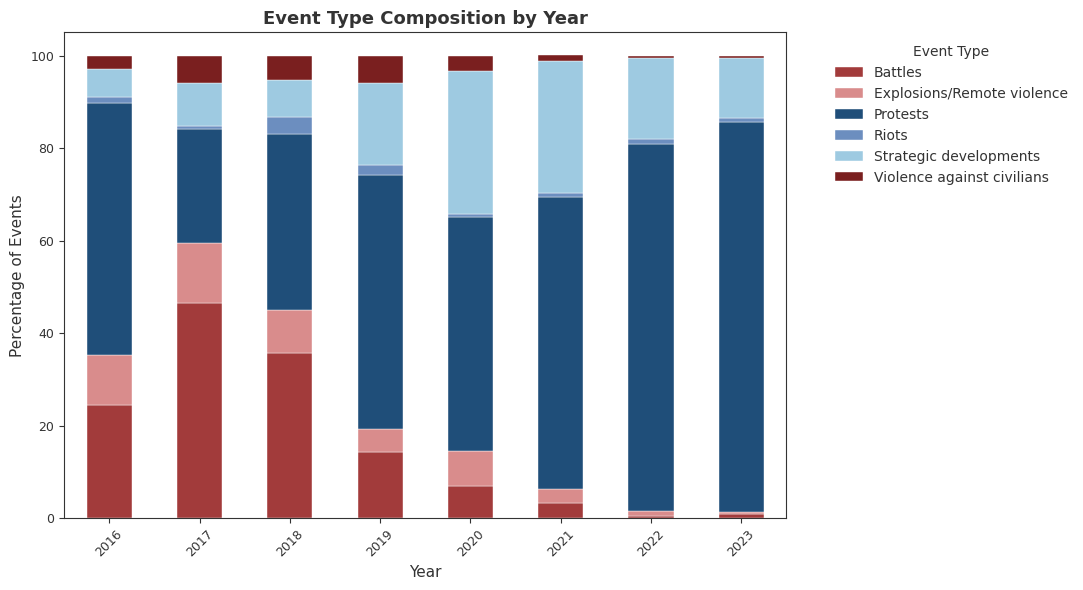

In [25]:
# EDA CELL 06 — Event Type Distribution by Year

print("=== EVENT TYPE DISTRIBUTION BY YEAR ===")

# Count event types within each year.
# This table shows how the composition of events changes over time.
event_type_by_year = pd.crosstab(
    df_eda["year"],
    df_eda["event_type"]
)

print("\nEvent type counts by year:")
display(event_type_by_year)

# Convert counts to row percentages.
# Percentages are useful because yearly total counts are very different.
event_type_by_year_percent = event_type_by_year.div(
    event_type_by_year.sum(axis=1),
    axis=0
) * 100

event_type_by_year_percent = event_type_by_year_percent.round(2)

print("\nEvent type percentages by year:")
display(event_type_by_year_percent)

# Plot percentage distribution by year.
# This is usually more informative than raw yearly event counts.
plot_colors = [
    EVENT_TYPE_COLORS.get(col, NEUTRAL)
    for col in event_type_by_year_percent.columns
]

event_type_by_year_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=plot_colors,
    edgecolor="white",
    linewidth=0.3
)

plt.title("Event Type Composition by Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Events")
plt.legend(title="Event Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# EDA CELL 07 — Event Type Summary

print("=== EVENT TYPE SUMMARY ===")

# This table summarizes how common each event type is
# and how often each event type includes at least one reported fatality.
# We keep this as a descriptive EDA table instead of using several separate plots.

event_type_summary = (
    df_eda
    .groupby("event_type", observed=True)
    .agg(
        event_count=("event_id_cnty", "count"),
        total_fatalities=("fatalities", "sum"),
        median_fatalities=("fatalities", "median"),
        fatal_event_rate=("fatal_event", "mean")
    )
)

# Convert event count and fatal event rate into percentages.
event_type_summary["event_percent"] = (
    event_type_summary["event_count"] / len(df_eda) * 100
)

event_type_summary["fatal_event_rate_percent"] = (
    event_type_summary["fatal_event_rate"] * 100
)

# Select and order the final columns.
event_type_summary_display = event_type_summary[
    [
        "event_count",
        "event_percent",
        "total_fatalities",
        "median_fatalities",
        "fatal_event_rate_percent"
    ]
].sort_values("event_count", ascending=False).round(3)

display(event_type_summary_display)

=== EVENT TYPE SUMMARY ===


,event_count,event_percent,total_fatalities,median_fatalities,fatal_event_rate_percent
event_type,,,,,
Protests,12782,57.811,1,0.000,0.008
Strategic developments,4198,18.987,16,0.000,0.191
Battles,2894,13.089,5061,1.000,53.870
Explosions/Remote violence,1294,5.853,1769,0.000,38.022
Violence against civilians,668,3.021,291,0.000,23.653
Riots,274,1.239,12,0.000,2.190


=== SPATIAL DISTRIBUTION OF EVENTS IN TURKEY ===
Number of events used in the map: 22110
Number of fatal events shown separately: 2224
Turkey boundary loaded from online Natural Earth source.


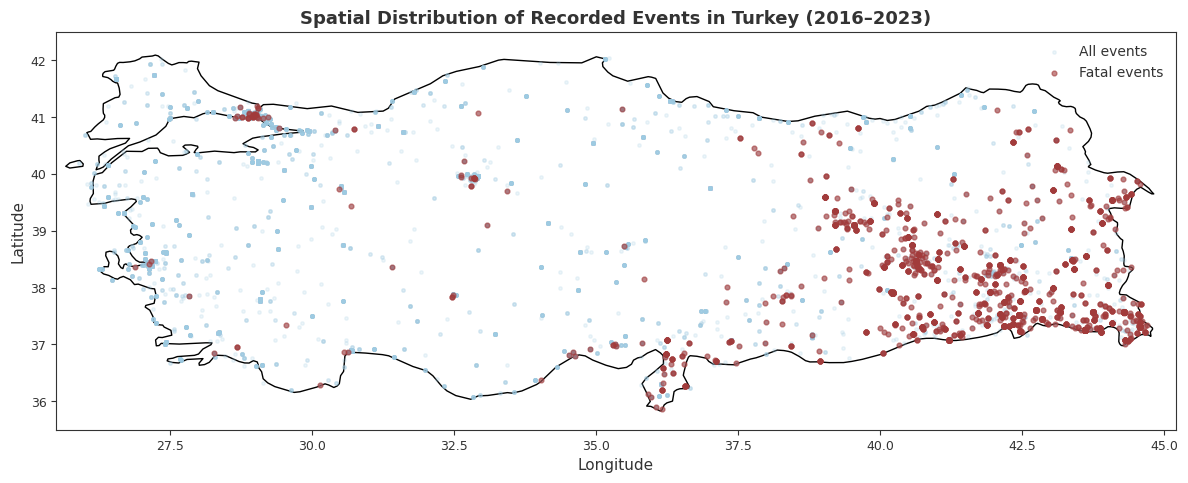

In [27]:
# EDA CELL 08 — Spatial Distribution of Events in Turkey

print("=== SPATIAL DISTRIBUTION OF EVENTS IN TURKEY ===")

import geopandas as gpd
from pathlib import Path

# Keep only observations with valid coordinate values.
df_map = df_eda.copy()

df_map["latitude"] = pd.to_numeric(df_map["latitude"], errors="coerce")
df_map["longitude"] = pd.to_numeric(df_map["longitude"], errors="coerce")

df_map = df_map[
    df_map["latitude"].between(-90, 90) &
    df_map["longitude"].between(-180, 180)
].copy()

print(f"Number of events used in the map: {df_map.shape[0]}")

# Separate fatal events so that they can be highlighted.
fatal_map = df_map[df_map["fatal_event"] == 1].copy()

print(f"Number of fatal events shown separately: {fatal_map.shape[0]}")

# Convert event data into GeoDataFrames.
gdf_events = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map["longitude"], df_map["latitude"]),
    crs="EPSG:4326"
)

gdf_fatal = gpd.GeoDataFrame(
    fatal_map,
    geometry=gpd.points_from_xy(fatal_map["longitude"], fatal_map["latitude"]),
    crs="EPSG:4326"
)

# Try to load Turkey boundary.
# A local Natural Earth file is preferred for reproducibility.
# If it is not available, the code tries the online source.
# If both fail, the map is still produced without the boundary.
turkey = None

local_boundary_path = Path("ne_50m_admin_0_countries.zip")
world_url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"

try:
    if local_boundary_path.exists():
        world = gpd.read_file(local_boundary_path)
        print("Turkey boundary loaded from local Natural Earth file.")
    else:
        world = gpd.read_file(world_url)
        print("Turkey boundary loaded from online Natural Earth source.")
    
    if "ADMIN" in world.columns:
        turkey = world[world["ADMIN"] == "Turkey"]
    elif "NAME" in world.columns:
        turkey = world[world["NAME"] == "Turkey"]
    else:
        turkey = None

except Exception as e:
    print("Turkey boundary could not be loaded.")
    print("Reason:", e)
    print("The map will be produced without the country boundary.")


fig, ax = plt.subplots(figsize=(12, 6))

# Plot Turkey boundary if available.
if turkey is not None and not turkey.empty:
    turkey.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=1.0
    )

# Plot all events as background points.
gdf_events.plot(
    ax=ax,
    markersize=6,
    color=SECONDARY,
    alpha=0.18,
    label="All events"
)

# Plot fatal events on top.
gdf_fatal.plot(
    ax=ax,
    markersize=12,
    color=ACCENT,
    alpha=0.60,
    label="Fatal events"
)

ax.set_title("Spatial Distribution of Recorded Events in Turkey (2016–2023)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_xlim(25.5, 45.2)
ax.set_ylim(35.5, 42.5)
ax.set_aspect("equal")

ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

=== POPULATION GROUPS AND EVENT SEVERITY ===

Event severity by population group:


,event_count,mean_fatalities,median_fatalities,fatal_event_rate_percent,civilian_targeted_rate_percent
population_group,,,,,
Low population,7376,0.438,0.000,16.418,4.948
Medium population,7374,0.130,0.000,4.082,1.614
High population,7360,0.403,0.000,9.674,6.889


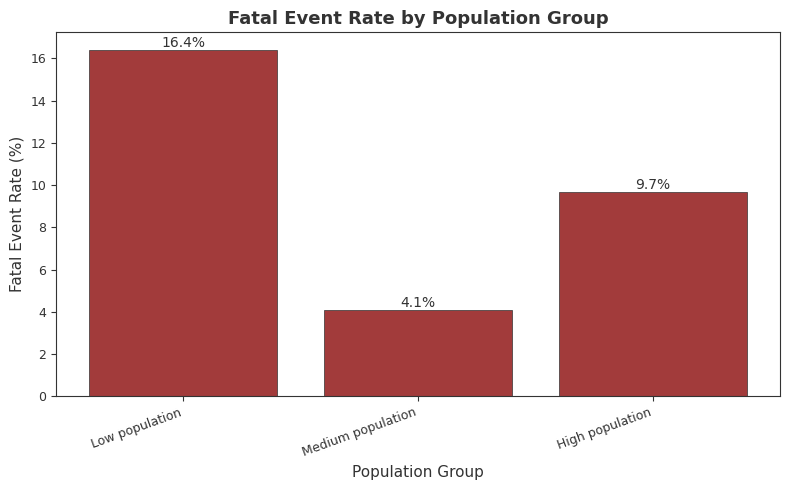

In [28]:
# EDA CELL 09 — Population Groups and Event Severity

print("=== POPULATION GROUPS AND EVENT SEVERITY ===")

# Make sure population and fatalities are numeric.
df_eda["population_for_analysis"] = pd.to_numeric(
    df_eda["population_for_analysis"],
    errors="coerce"
)

df_eda["fatalities"] = pd.to_numeric(
    df_eda["fatalities"],
    errors="coerce"
)

# Create three population groups using tertiles.
# This gives us low, medium, and high population groups with similar group sizes.
df_eda["population_group"] = pd.qcut(
    df_eda["population_for_analysis"],
    q=3,
    labels=[
        "Low population",
        "Medium population",
        "High population"
    ]
)

# Summarize event severity by population group.
population_group_summary = (
    df_eda
    .groupby("population_group", observed=True)
    .agg(
        event_count=("event_id_cnty", "count"),
        mean_fatalities=("fatalities", "mean"),
        median_fatalities=("fatalities", "median"),
        fatal_event_rate=("fatal_event", "mean"),
        civilian_targeted_rate=("civilian_targeted", "mean")
    )
)

# Convert proportions to percentages.
population_group_summary["fatal_event_rate_percent"] = (
    population_group_summary["fatal_event_rate"] * 100
)

population_group_summary["civilian_targeted_rate_percent"] = (
    population_group_summary["civilian_targeted_rate"] * 100
)

population_group_summary_display = population_group_summary[
    [
        "event_count",
        "mean_fatalities",
        "median_fatalities",
        "fatal_event_rate_percent",
        "civilian_targeted_rate_percent"
    ]
].round(3)

print("\nEvent severity by population group:")
display(population_group_summary_display)

# Plot fatal event rate by population group.
plt.figure(figsize=(8, 5))

bars = plt.bar(
    population_group_summary_display.index.astype(str),
    population_group_summary_display["fatal_event_rate_percent"],
    color=ACCENT,
    edgecolor=DARK,
    linewidth=0.5
)

plt.title("Fatal Event Rate by Population Group")
plt.xlabel("Population Group")
plt.ylabel("Fatal Event Rate (%)")
plt.xticks(rotation=20, ha="right")

# Add percentage labels above the bars.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

=== PROVINCE-LEVEL EVENT SUMMARY ===

Top 15 provinces by number of recorded events:


,event_count,total_fatalities,mean_fatalities,fatal_event_rate_percent,civilian_targeted_rate_percent
admin1,,,,,
Istanbul,3577,286,0.080,0.755,4.082
Ankara,1956,175,0.089,0.665,3.016
Diyarbakir,1866,666,0.357,13.183,5.788
Hakkari,1378,1598,1.160,33.019,4.427
Izmir,1322,8,0.006,0.227,2.799
Sirnak,1001,1501,1.500,41.858,5.694
Van,861,365,0.424,15.215,7.317
Mardin,550,412,0.749,28.182,9.636
Tunceli,503,463,0.920,30.219,2.386



Top 15 provinces by total reported fatalities:


,event_count,total_fatalities,mean_fatalities,fatal_event_rate_percent,civilian_targeted_rate_percent
admin1,,,,,
Hakkari,1378,1598,1.160,33.019,4.427
Sirnak,1001,1501,1.500,41.858,5.694
Diyarbakir,1866,666,0.357,13.183,5.788
Tunceli,503,463,0.920,30.219,2.386
Mardin,550,412,0.749,28.182,9.636
Van,861,365,0.424,15.215,7.317
Siirt,311,319,1.026,36.013,4.180
Istanbul,3577,286,0.080,0.755,4.082
Bitlis,385,222,0.577,22.078,1.558


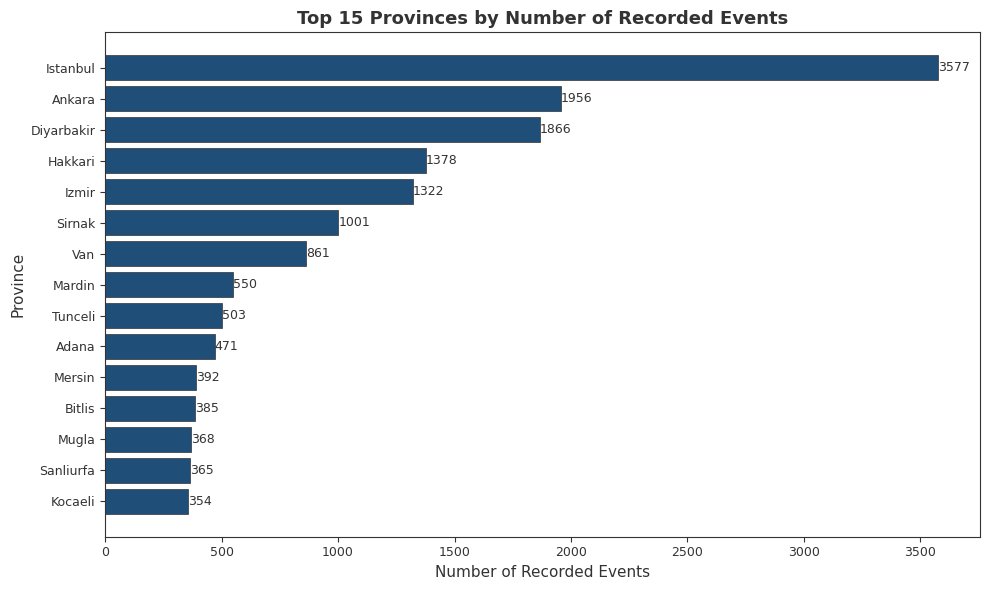

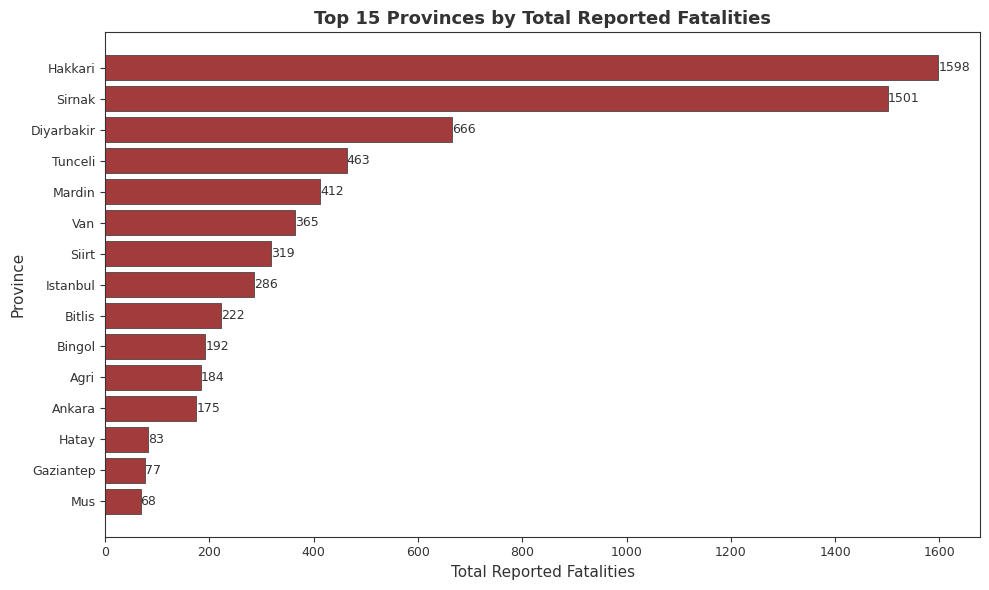

In [29]:
# EDA CELL 10 — Province-Level Event Summary

print("=== PROVINCE-LEVEL EVENT SUMMARY ===")

# admin1 represents the first-level administrative region.
# For Turkey, this works like province-level information in our dataset.
df_eda["admin1"] = df_eda["admin1"].astype("string")

# Summarize event count and severity by admin1.
province_summary = (
    df_eda
    .groupby("admin1", observed=True)
    .agg(
        event_count=("event_id_cnty", "count"),
        total_fatalities=("fatalities", "sum"),
        mean_fatalities=("fatalities", "mean"),
        fatal_event_rate=("fatal_event", "mean"),
        civilian_targeted_rate=("civilian_targeted", "mean")
    )
)

# Convert proportions to percentages.
province_summary["fatal_event_rate_percent"] = (
    province_summary["fatal_event_rate"] * 100
)

province_summary["civilian_targeted_rate_percent"] = (
    province_summary["civilian_targeted_rate"] * 100
)

province_summary_display = province_summary[
    [
        "event_count",
        "total_fatalities",
        "mean_fatalities",
        "fatal_event_rate_percent",
        "civilian_targeted_rate_percent"
    ]
].round(3)

# Show provinces with the highest number of recorded events.
top_provinces_by_events = (
    province_summary_display
    .sort_values("event_count", ascending=False)
    .head(15)
)

print("\nTop 15 provinces by number of recorded events:")
display(top_provinces_by_events)

# Show provinces with the highest total reported fatalities.
top_provinces_by_fatalities = (
    province_summary_display
    .sort_values("total_fatalities", ascending=False)
    .head(15)
)

print("\nTop 15 provinces by total reported fatalities:")
display(top_provinces_by_fatalities)


# ---------------------------------------------------------
# Visualization 1 — Top provinces by event count
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plot_data_events = top_provinces_by_events.sort_values(
    "event_count",
    ascending=True
)

bars = plt.barh(
    plot_data_events.index.astype(str),
    plot_data_events["event_count"],
    color=PRIMARY,
    edgecolor=DARK,
    linewidth=0.5
)

plt.title("Top 15 Provinces by Number of Recorded Events")
plt.xlabel("Number of Recorded Events")
plt.ylabel("Province")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Visualization 2 — Top provinces by total reported fatalities
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plot_data_fatalities = top_provinces_by_fatalities.sort_values(
    "total_fatalities",
    ascending=True
)

bars = plt.barh(
    plot_data_fatalities.index.astype(str),
    plot_data_fatalities["total_fatalities"],
    color=ACCENT,
    edgecolor=DARK,
    linewidth=0.5
)

plt.title("Top 15 Provinces by Total Reported Fatalities")
plt.xlabel("Total Reported Fatalities")
plt.ylabel("Province")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()

=== SOURCE SCALE AND SOURCE COUNT SUMMARY ===

Source scale distribution:


,event_count,percent
source_scale,,
National,12854,58.137
Other,3364,15.215
International,2952,13.351
National-International,1212,5.482
Other-National,775,3.505
National-Regional,248,1.122
Other-International,210,0.950
Subnational,195,0.882
Local partner-New media,78,0.353


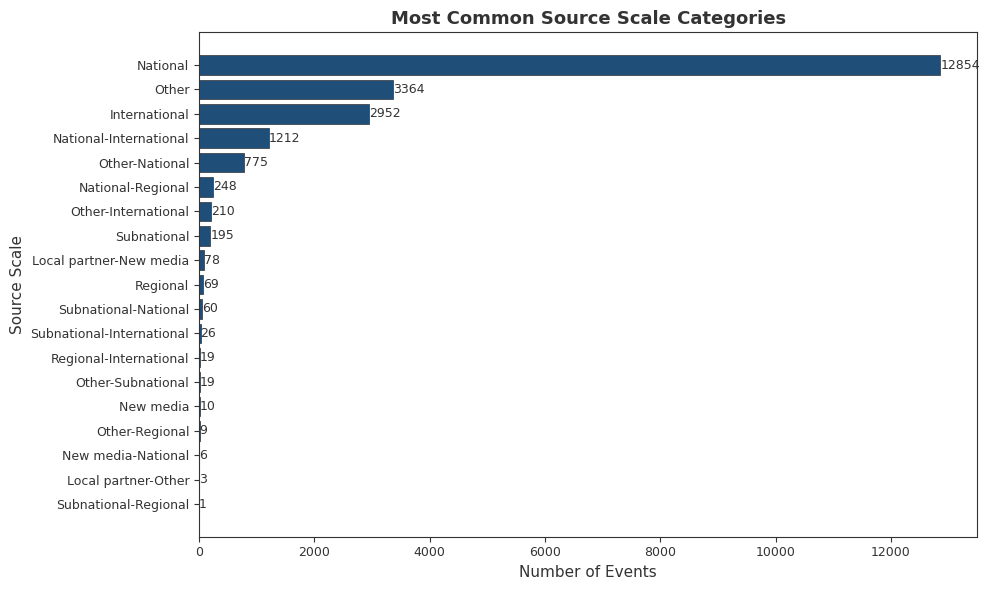


Source count distribution:


,event_count,percent
source_count,,
1,17239,77.969
2,3372,15.251
3,1043,4.717
4,386,1.746
5,58,0.262
6,10,0.045
7,1,0.005
9,1,0.005


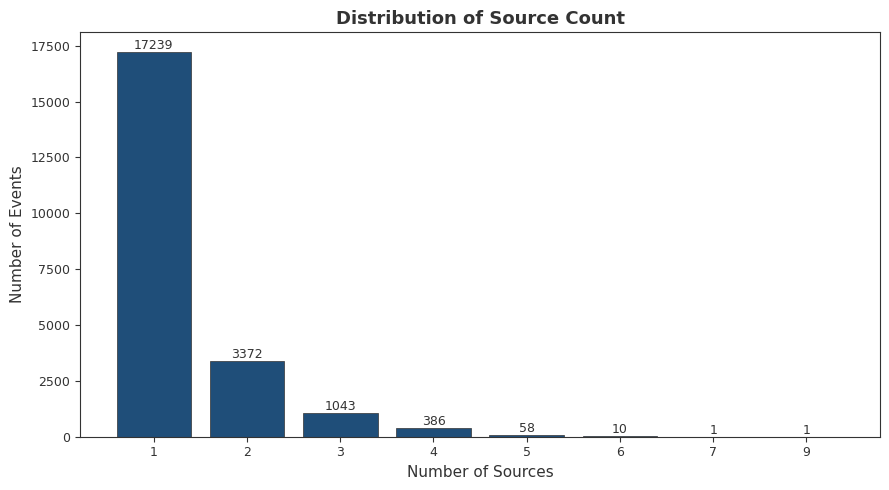

In [30]:
# EDA CELL 11 — Source Scale and Source Count Summary

print("=== SOURCE SCALE AND SOURCE COUNT SUMMARY ===")

# Make sure source_count is numeric.
df_eda["source_count"] = pd.to_numeric(df_eda["source_count"], errors="coerce")

# ---------------------------------------------------------
# Part A — Source scale categories
# ---------------------------------------------------------

source_scale_summary = (
    df_eda["source_scale"]
    .value_counts(dropna=False)
    .to_frame("event_count")
)

source_scale_summary["percent"] = (
    source_scale_summary["event_count"] / len(df_eda) * 100
)

source_scale_summary = source_scale_summary.round(3)

print("\nSource scale distribution:")
display(source_scale_summary)


# Plot source scale distribution as a horizontal bar chart.
plt.figure(figsize=(10, 6))

plot_source_scale = source_scale_summary.sort_values(
    "event_count",
    ascending=True
)

bars = plt.barh(
    plot_source_scale.index.astype(str),
    plot_source_scale["event_count"],
    color=PRIMARY,
    edgecolor=DARK,
    linewidth=0.5
)

plt.title("Most Common Source Scale Categories")
plt.xlabel("Number of Events")
plt.ylabel("Source Scale")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Part B — Source count distribution
# ---------------------------------------------------------

source_count_summary = (
    df_eda["source_count"]
    .value_counts()
    .sort_index()
    .to_frame("event_count")
)

source_count_summary["percent"] = (
    source_count_summary["event_count"] / len(df_eda) * 100
)

source_count_summary = source_count_summary.round(3)

print("\nSource count distribution:")
display(source_count_summary)


# Plot source count distribution.
plt.figure(figsize=(9, 5))

bars = plt.bar(
    source_count_summary.index.astype(str),
    source_count_summary["event_count"],
    color=PRIMARY,
    edgecolor=DARK,
    linewidth=0.5
    
)

plt.title("Distribution of Source Count")
plt.xlabel("Number of Sources")
plt.ylabel("Number of Events")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

=== ACTOR COUNT AND EVENT SEVERITY ===


,event_count,fatal_event_count,fatal_event_rate_percent,mean_fatalities
actor_count,,,,
1,11897,18,0.151,0.003
2,10213,2206,21.600,0.697


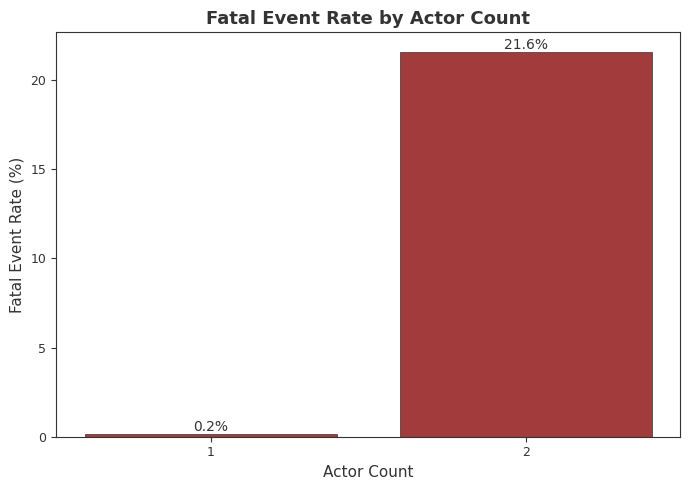

In [31]:
# EDA CELL 12 — Actor Count and Event Severity

print("=== ACTOR COUNT AND EVENT SEVERITY ===")

# Make sure actor count is numeric.
df_eda["actor_count"] = pd.to_numeric(df_eda["actor_count"], errors="coerce")

# Summarize event severity by actor_count.
# This checks whether single-actor and two-actor events differ descriptively.
actor_count_summary = (
    df_eda
    .groupby("actor_count", observed=True)
    .agg(
        event_count=("event_id_cnty", "count"),
        fatal_event_count=("fatal_event", "sum"),
        fatal_event_rate=("fatal_event", "mean"),
        mean_fatalities=("fatalities", "mean")
    )
)

# Convert fatal event rate to percentage.
actor_count_summary["fatal_event_rate_percent"] = (
    actor_count_summary["fatal_event_rate"] * 100
)

actor_count_summary_display = actor_count_summary[
    [
        "event_count",
        "fatal_event_count",
        "fatal_event_rate_percent",
        "mean_fatalities"
    ]
].round(3)

display(actor_count_summary_display)

# Plot fatal event rate by actor count.
plt.figure(figsize=(7, 5))

bars = plt.bar(
    actor_count_summary_display.index.astype(str),
    actor_count_summary_display["fatal_event_rate_percent"],
    color=ACCENT,
    edgecolor=DARK,
    linewidth=0.5
)

plt.title("Fatal Event Rate by Actor Count")
plt.xlabel("Actor Count")
plt.ylabel("Fatal Event Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

=== SPEARMAN CORRELATION CHECK FOR SELECTED VARIABLES ===

Spearman correlation matrix:


,fatalities,fatal_event,civilian_targeted,violent_event,log_population,actor_count,assoc_actor_count,source_count,time_precision,geo_precision
fatalities,1.000,0.998,0.094,0.604,-0.101,0.355,-0.281,0.141,0.035,0.292
fatal_event,0.998,1.000,0.100,0.605,-0.102,0.356,-0.282,0.140,0.032,0.290
civilian_targeted,0.094,0.100,1.000,0.386,0.033,0.234,-0.010,0.023,0.078,0.010
violent_event,0.604,0.605,0.386,1.000,-0.051,0.528,-0.386,0.051,0.068,0.376
log_population,-0.101,-0.102,0.033,-0.051,1.000,0.086,0.030,0.004,-0.010,0.166
actor_count,0.355,0.356,0.234,0.528,0.086,1.000,-0.191,0.050,0.294,0.486
assoc_actor_count,-0.281,-0.282,-0.010,-0.386,0.030,-0.191,1.000,0.068,-0.062,-0.322
source_count,0.141,0.140,0.023,0.051,0.004,0.050,0.068,1.000,0.053,0.074
time_precision,0.035,0.032,0.078,0.068,-0.010,0.294,-0.062,0.053,1.000,0.310
geo_precision,0.292,0.290,0.010,0.376,0.166,0.486,-0.322,0.074,0.310,1.000


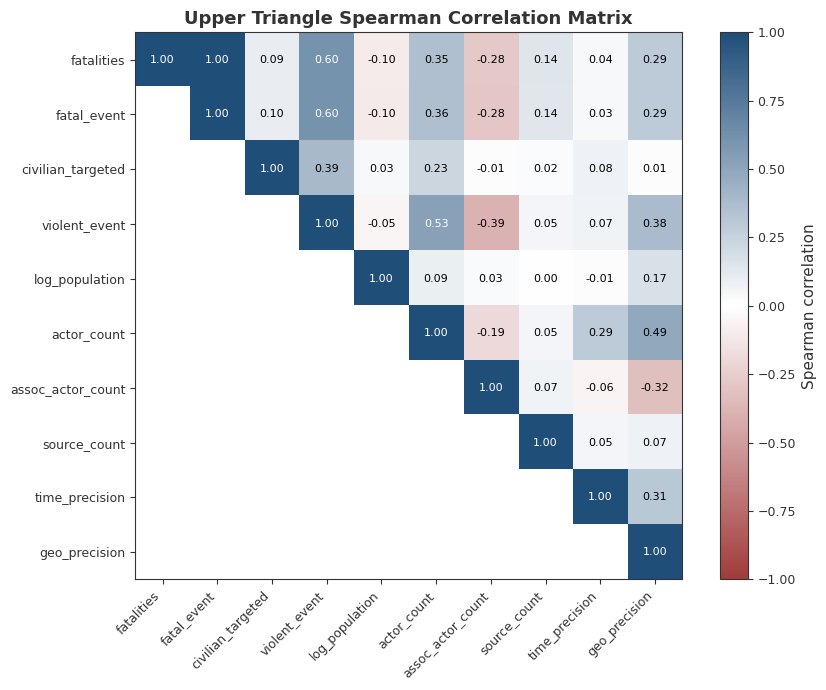


Note:
Only the upper triangle is shown because the correlation matrix is symmetric.
The high correlation between fatalities and fatal_event is expected because fatal_event was created from fatalities.


In [32]:
# EDA CELL 13 — Spearman Correlation Check for Selected Variables

print("=== SPEARMAN CORRELATION CHECK FOR SELECTED VARIABLES ===")

# Select variables that may be related to event severity.
# ID variables are not included because they do not have statistical meaning.
corr_cols = [
    "fatalities",
    "fatal_event",
    "civilian_targeted",
    "violent_event",
    "log_population",
    "actor_count",
    "assoc_actor_count",
    "source_count",
    "time_precision",
    "geo_precision"
]

corr_cols = [col for col in corr_cols if col in df_eda.columns]

# Make sure selected variables are numeric.
for col in corr_cols:
    df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

# Spearman correlation is used because several variables are binary, discrete, or skewed.
spearman_corr = df_eda[corr_cols].corr(method="spearman").round(3)

print("\nSpearman correlation matrix:")
display(spearman_corr)


# Plot only the upper triangle of the Spearman correlation matrix.
# The full correlation matrix is symmetric, so the lower triangle would repeat the same information.
mask = np.tril(np.ones_like(spearman_corr, dtype=bool), k=-1)

masked_corr = np.ma.masked_where(mask, spearman_corr)

fig, ax = plt.subplots(figsize=(9, 7))

cmap = PROJECT_CMAP.copy()
cmap.set_bad(color="white")


im = ax.imshow(masked_corr, vmin=-1, vmax=1, cmap=cmap)

ax.set_xticks(range(len(spearman_corr.columns)))
ax.set_yticks(range(len(spearman_corr.index)))

ax.set_xticklabels(spearman_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(spearman_corr.index)

# Add correlation values only to the visible upper triangle.
for i in range(len(spearman_corr.index)):
    for j in range(len(spearman_corr.columns)):
        if not mask[i, j]:
            value = spearman_corr.iloc[i, j]
            text_color = "white" if abs(value) >= 0.50 else "black"

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=8
            )

plt.title("Upper Triangle Spearman Correlation Matrix")
plt.colorbar(im, ax=ax, label="Spearman correlation")

plt.tight_layout()
plt.show()

print("\nNote:")
print("Only the upper triangle is shown because the correlation matrix is symmetric.")
print("The high correlation between fatalities and fatal_event is expected because fatal_event was created from fatalities.")

In [33]:
# EDA CELL 14 — Fatal Event Rate by Selected Categories

print("=== FATAL EVENT RATE BY SELECTED CATEGORIES ===")

# These tables show the percentage distribution of fatal_event within each group.
# This is useful for descriptive comparison before formal statistical tests.

# 1. Event type by fatal event status
event_type_fatal_percent = (
    pd.crosstab(
        df_eda["event_type"],
        df_eda["fatal_event"],
        normalize="index"
    ) * 100
).round(2)

event_type_fatal_percent = event_type_fatal_percent.rename(
    columns={
        0: "No fatality (%)",
        1: "At least one fatality (%)"
    }
)

print("\n1. Event type by fatal event status — row percentages:")
display(event_type_fatal_percent)


# 2. Violent event group by fatal event status
violent_fatal_percent = (
    pd.crosstab(
        df_eda["violent_event"],
        df_eda["fatal_event"],
        normalize="index"
    ) * 100
).round(2)

violent_fatal_percent = violent_fatal_percent.rename(
    index={
        0: "Non-violent event",
        1: "Violent event"
    },
    columns={
        0: "No fatality (%)",
        1: "At least one fatality (%)"
    }
)

print("\n2. Violent event group by fatal event status — row percentages:")
display(violent_fatal_percent)

=== FATAL EVENT RATE BY SELECTED CATEGORIES ===

1. Event type by fatal event status — row percentages:


fatal_event,No fatality (%),At least one fatality (%)
event_type,,
Battles,46.130,53.870
Explosions/Remote violence,61.980,38.020
Protests,99.990,0.010
Riots,97.810,2.190
Strategic developments,99.810,0.190
Violence against civilians,76.350,23.650



2. Violent event group by fatal event status — row percentages:


fatal_event,No fatality (%),At least one fatality (%)
violent_event,,
Non-violent event,99.950,0.050
Violent event,56.820,43.180


=== DISTRIBUTION OF REPORTED FATALITIES ===

Fatality count distribution:


,event_count,percent
fatalities,,
0,19886,89.940
1,869,3.930
2,538,2.430
3,254,1.150
4,156,0.710
5,110,0.500
6,70,0.320
7,55,0.250
8,43,0.190



Grouped fatality distribution:


,event_count,percent
fatality_group,,
0 fatalities,19886,89.940
1 fatality,869,3.930
2-5 fatalities,1058,4.790
6-10 fatalities,221,1.000
More than 10 fatalities,76,0.340


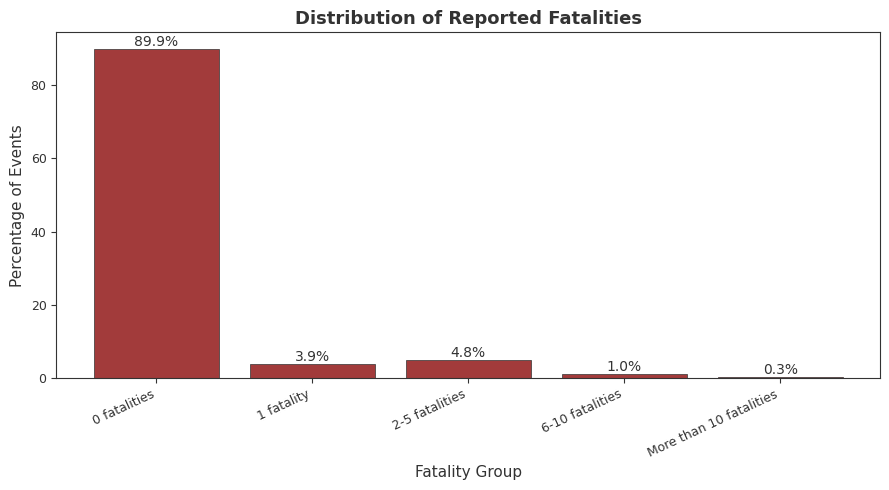

In [34]:
# EDA CELL 15 — Distribution of Reported Fatalities

print("=== DISTRIBUTION OF REPORTED FATALITIES ===")

# Make sure fatalities is numeric.
df_eda["fatalities"] = pd.to_numeric(df_eda["fatalities"], errors="coerce")

# Basic frequency table for small fatality counts.
# Many events have zero fatalities, so this helps us see the zero-heavy structure.
fatality_count_table = (
    df_eda["fatalities"]
    .value_counts()
    .sort_index()
    .to_frame("event_count")
)

fatality_count_table["percent"] = (
    fatality_count_table["event_count"] / len(df_eda) * 100
).round(2)

print("\nFatality count distribution:")
display(fatality_count_table.head(15))


# Create grouped fatality categories for easier interpretation.
# This is only for descriptive EDA.
df_eda["fatality_group"] = pd.cut(
    df_eda["fatalities"],
    bins=[-0.1, 0, 1, 5, 10, df_eda["fatalities"].max()],
    labels=[
        "0 fatalities",
        "1 fatality",
        "2-5 fatalities",
        "6-10 fatalities",
        "More than 10 fatalities"
    ]
)

fatality_group_table = (
    df_eda["fatality_group"]
    .value_counts()
    .reindex([
        "0 fatalities",
        "1 fatality",
        "2-5 fatalities",
        "6-10 fatalities",
        "More than 10 fatalities"
    ])
    .to_frame("event_count")
)

fatality_group_table["percent"] = (
    fatality_group_table["event_count"] / len(df_eda) * 100
).round(2)

print("\nGrouped fatality distribution:")
display(fatality_group_table)


# Plot grouped fatality distribution.
plt.figure(figsize=(9, 5))

bars = plt.bar(
    fatality_group_table.index.astype(str),
    fatality_group_table["percent"],
    color=ACCENT,
    edgecolor=DARK,
    linewidth=0.5
)

plt.title("Distribution of Reported Fatalities")
plt.xlabel("Fatality Group")
plt.ylabel("Percentage of Events")
plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

=== YEARLY TRENDS IN RECORDED EVENTS AND FATALITIES ===

Yearly summary table:


,year,event_count,total_fatalities,fatal_events,fatal_event_rate_percent,violent_events,violent_event_rate_percent
0,2016,3129,2601,700,22.371,1238,39.565
1,2017,1259,2452,656,52.105,834,66.243
2,2018,1627,970,350,21.512,877,53.903
3,2019,3335,548,252,7.556,911,27.316
4,2020,4220,340,150,3.555,776,18.389
5,2021,4749,208,97,2.043,393,8.275
6,2022,434,2,2,0.461,14,3.226
7,2023,3357,29,17,0.506,87,2.592


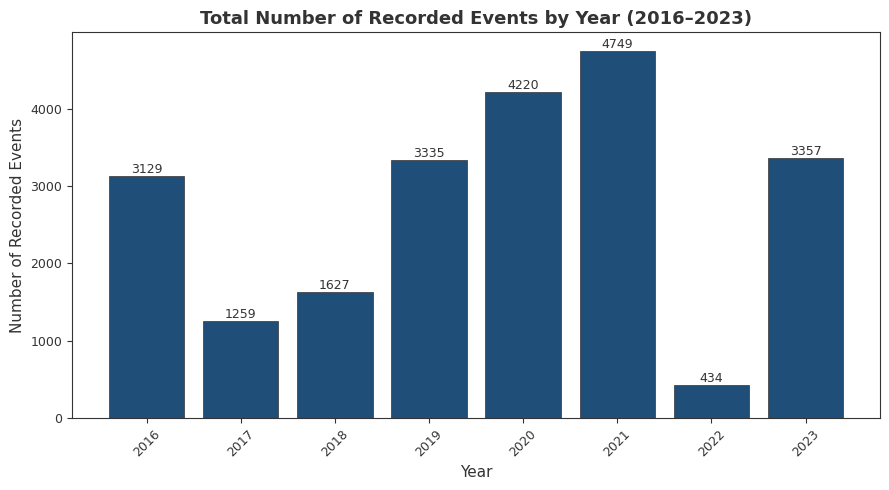

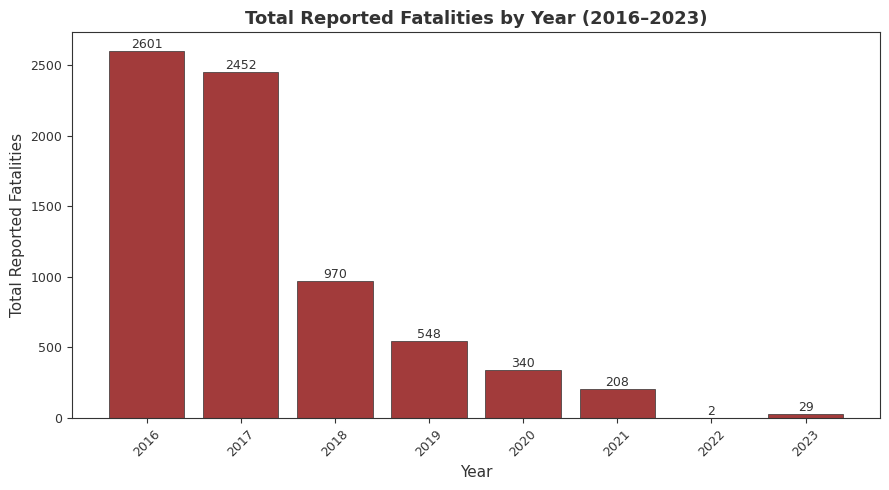

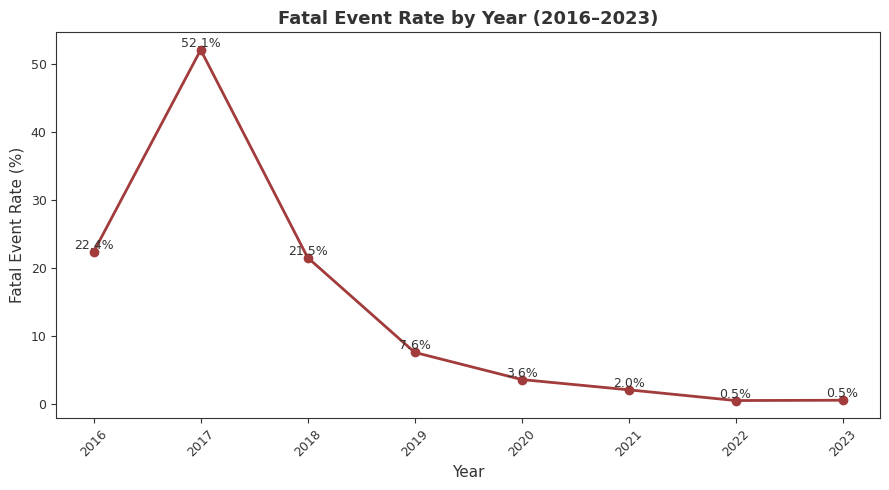

In [35]:
# EDA CELL 16 — Yearly Trends in Recorded Events and Fatalities

print("=== YEARLY TRENDS IN RECORDED EVENTS AND FATALITIES ===")

# Make sure year and fatalities have the correct format.
df_eda["year"] = pd.to_numeric(df_eda["year"], errors="coerce")
df_eda["fatalities"] = pd.to_numeric(df_eda["fatalities"], errors="coerce")

# Summarize key event indicators by year.
yearly_summary = (
    df_eda
    .dropna(subset=["year"])
    .groupby("year", observed=True)
    .agg(
        event_count=("event_id_cnty", "count"),
        total_fatalities=("fatalities", "sum"),
        fatal_events=("fatal_event", "sum"),
        fatal_event_rate=("fatal_event", "mean"),
        violent_events=("violent_event", "sum"),
        violent_event_rate=("violent_event", "mean")
    )
    .reset_index()
    .sort_values("year")
)

# Convert year to integer for cleaner display.
yearly_summary["year"] = yearly_summary["year"].astype(int)

# Convert proportions to percentages.
yearly_summary["fatal_event_rate_percent"] = (
    yearly_summary["fatal_event_rate"] * 100
)

yearly_summary["violent_event_rate_percent"] = (
    yearly_summary["violent_event_rate"] * 100
)

yearly_summary_display = yearly_summary[
    [
        "year",
        "event_count",
        "total_fatalities",
        "fatal_events",
        "fatal_event_rate_percent",
        "violent_events",
        "violent_event_rate_percent"
    ]
].round(3)

print("\nYearly summary table:")
display(yearly_summary_display)


# Plot 1: Total recorded events by year.
plt.figure(figsize=(9, 5))

bars = plt.bar(
    yearly_summary["year"].astype(str),
    yearly_summary["event_count"],
    color=PRIMARY,
    edgecolor=DARK,
    linewidth=0.5
)

plt.title("Total Number of Recorded Events by Year (2016–2023)")
plt.xlabel("Year")
plt.ylabel("Number of Recorded Events")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# Plot 2: Total reported fatalities by year.
plt.figure(figsize=(9, 5))

bars = plt.bar(
    yearly_summary["year"].astype(str),
    yearly_summary["total_fatalities"],
    color=ACCENT,
    edgecolor=DARK,
    linewidth=0.5
)

plt.title("Total Reported Fatalities by Year (2016–2023)")
plt.xlabel("Year")
plt.ylabel("Total Reported Fatalities")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# Plot 3: Fatal event rate by year.
plt.figure(figsize=(9, 5))

plt.plot(
    yearly_summary["year"].astype(str),
    yearly_summary["fatal_event_rate_percent"],
    marker="o",
    color=ACCENT,
    linewidth=2
)

plt.title("Fatal Event Rate by Year (2016–2023)")
plt.xlabel("Year")
plt.ylabel("Fatal Event Rate (%)")
plt.xticks(rotation=45)

for x, y in zip(
    yearly_summary["year"].astype(str),
    yearly_summary["fatal_event_rate_percent"]
):
    plt.text(
        x,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [36]:
# EDA CELL 17 — Summary of Main EDA Findings

print("=== SUMMARY OF MAIN EDA FINDINGS ===")

# This cell gives a short summary of the main descriptive findings.
# It does not perform any statistical test.

total_events = df_eda.shape[0]

fatal_events = int(df_eda["fatal_event"].sum())
fatal_event_rate = df_eda["fatal_event"].mean() * 100

violent_events = int(df_eda["violent_event"].sum())
violent_event_rate = df_eda["violent_event"].mean() * 100

civilian_targeted_events = int(df_eda["civilian_targeted"].sum())
civilian_targeted_rate = df_eda["civilian_targeted"].mean() * 100

total_fatalities = df_eda["fatalities"].sum()
mean_fatalities = df_eda["fatalities"].mean()
median_fatalities = df_eda["fatalities"].median()

print(f"Total number of events: {total_events}")
print(f"Total reported fatalities: {total_fatalities:.0f}")

print("\nEvent severity:")
print(f"Number of fatal events: {fatal_events}")
print(f"Fatal event rate: {fatal_event_rate:.2f}%")
print(f"Mean reported fatalities per event: {mean_fatalities:.3f}")
print(f"Median reported fatalities per event: {median_fatalities:.3f}")

print("\nDerived event indicators:")
print(f"Number of violent events: {violent_events}")
print(f"Violent event rate: {violent_event_rate:.2f}%")
print(f"Number of civilian-targeted events: {civilian_targeted_events}")
print(f"Civilian targeting rate: {civilian_targeted_rate:.2f}%")

print("\nMain EDA notes:")
print("- Most events have zero reported fatalities.")
print("- Therefore, fatal_event is useful as a binary severity indicator.")
print("- Protests are the most common event type, but they rarely include fatalities.")
print("- Battles and explosions/remote violence have higher fatal event rates.")
print("- Fatal events appear more concentrated in eastern and southeastern Turkey.")
print("- Population does not show a simple linear relationship with fatal event status.")

=== SUMMARY OF MAIN EDA FINDINGS ===
Total number of events: 22110
Total reported fatalities: 7150

Event severity:
Number of fatal events: 2224
Fatal event rate: 10.06%
Mean reported fatalities per event: 0.323
Median reported fatalities per event: 0.000

Derived event indicators:
Number of violent events: 5130
Violent event rate: 23.20%
Number of civilian-targeted events: 991
Civilian targeting rate: 4.48%

Main EDA notes:
- Most events have zero reported fatalities.
- Therefore, fatal_event is useful as a binary severity indicator.
- Protests are the most common event type, but they rarely include fatalities.
- Battles and explosions/remote violence have higher fatal event rates.
- Fatal events appear more concentrated in eastern and southeastern Turkey.
- Population does not show a simple linear relationship with fatal event status.


# Statistical Analysis and Research Questions

This section applies formal statistical methods to answer research questions about the cleaned event-level dataset.

The analysis focuses on recorded political violence and protest events in Turkey. The main aim is to examine event composition, fatality status, reporting coverage, population context, and event severity.

The research questions are:

1. **Are protests the majority of recorded events, and is fatality status associated with event type?**  
   This question examines whether protests dominate the dataset and whether fatality status differs by event type.

2. **Do violent and non-violent events differ in fatal event rate?**  
   This question compares the probability of observing at least one reported fatality between violent and non-violent events.

3. **Are more severe events associated with broader reporting coverage?**  
   This question examines whether fatal events have higher reporting coverage, measured by source count.

4. **Do event types differ in their population context?**  
   This question examines whether different event types tend to be recorded in areas with different population levels.

5. **Which variables are associated with event severity among recorded events?**  
   This question models event severity using event characteristics and population context.

For each research question, the statistical method is selected according to the type of response variable and explanatory variable. Assumptions are checked before interpreting the results. When assumptions are not fully reasonable, more appropriate alternatives or robustness checks are used.

Since the dataset is observational, the results are interpreted as associations rather than causal effects.

In [37]:
# ANALYSIS CELL 00 — Setup for Statistical Analysis

print("=== SETUP FOR STATISTICAL ANALYSIS ===")

# Statistical tests and models
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera

import statsmodels.api as sm
import statsmodels.formula.api as smf

from itertools import combinations

# Display numerical outputs with 3 decimals.
pd.set_option("display.float_format", "{:.3f}".format)

# Helper function for cleaner p-value display.
# Very small p-values are shown as <0.001 instead of 0.000.
def format_p_value(p):
    if p < 0.001:
        return "<0.001"
    else:
        return f"{p:.3f}"

# Work on a copy of the EDA dataset.
# This avoids changing df_eda while performing statistical analyses.
df_analysis = df_eda.copy()

# Make sure the main variables have the correct formats.
df_analysis["event_type"] = df_analysis["event_type"].astype("string")

numeric_analysis_cols = [
    "fatalities",
    "fatal_event",
    "violent_event",
    "civilian_targeted",
    "source_count",
    "actor_count",
    "assoc_actor_count",
    "log_population",
    "population_for_analysis"
]

numeric_analysis_cols = [
    col for col in numeric_analysis_cols
    if col in df_analysis.columns
]

for col in numeric_analysis_cols:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors="coerce")

# Event severity transformation for regression.
# log(1 + fatalities) is used because fatalities is highly skewed and zero-heavy.
df_analysis["log_fatalities"] = np.log1p(df_analysis["fatalities"])

# Short overview of variables used in statistical analysis.
analysis_variables = [
    "event_type",
    "fatalities",
    "fatal_event",
    "violent_event",
    "source_count",
    "actor_count",
    "log_population",
    "log_fatalities"
]

analysis_variables = [
    col for col in analysis_variables
    if col in df_analysis.columns
]

print(f"Rows in analysis dataset: {df_analysis.shape[0]}")

print("\nPreview of main analysis variables:")
display(
    df_analysis[analysis_variables].head(10)
)

=== SETUP FOR STATISTICAL ANALYSIS ===
Rows in analysis dataset: 22110

Preview of main analysis variables:


,event_type,fatalities,fatal_event,violent_event,source_count,actor_count,log_population,log_fatalities
0,Battles,4,1,1,1,2,11.350,1.609
1,Battles,5,1,1,1,2,11.495,1.792
2,Battles,0,0,1,1,2,10.675,0.000
3,Explosions/Remote violence,1,1,1,1,2,11.350,0.693
4,Explosions/Remote violence,2,1,1,1,2,10.675,1.099
5,Riots,0,0,1,1,2,11.957,0.000
6,Violence against civilians,1,1,1,1,2,11.495,0.693
7,Battles,1,1,1,1,2,11.442,0.693
8,Battles,2,1,1,1,2,10.675,1.099
9,Protests,0,0,0,1,2,10.286,0.000


## RQ1 — Event Type Composition and Fatality Status

This research question examines the composition of recorded events and whether fatality status differs by event type.

**Research Question 1:**  
Are protests the majority of recorded events, and is fatality status associated with event type?

This question is analyzed in two parts:

1. A one-sample proportion z-test is used to test whether protest events make up more than half of all recorded events.
2. A chi-square test of independence is used to test whether `event_type` and `fatal_event` are statistically associated.

For the one-sample proportion test, let <i>p</i> be the population proportion of recorded events classified as protests.

<p><b>H<sub>0</sub>:</b> p = 0.50</p>

<p><b>H<sub>A</sub>:</b> p > 0.50</p>

For the chi-square test, the hypotheses are:

<p><b>H<sub>0</sub>:</b> event_type and fatal_event are independent.</p>

<p><b>H<sub>A</sub>:</b> event_type and fatal_event are associated.</p>

In [38]:
# ANALYSIS CELL 01 — RQ1: Event Type Composition and Fatality Status

print("=== RQ1: EVENT TYPE COMPOSITION AND FATALITY STATUS ===")
   
alpha = 0.05

# Use only rows with event_type and fatal_event available.
rq1_data = df_analysis[["event_type", "fatal_event"]].dropna().copy()

rq1_data["fatal_event"] = pd.to_numeric(
    rq1_data["fatal_event"],
    errors="coerce"
)

rq1_data = rq1_data.dropna(subset=["fatal_event"]).copy()

print("\nResearch Question 1:")
print("Are protests the majority of recorded events, and is fatality status associated with event type?")


# ---------------------------------------------------------
# Part A — One-sample proportion test for protest majority
# ---------------------------------------------------------

print("\n--- Part A: One-Sample Proportion Test ---")

# Success is defined as an event being classified as "Protests".
is_protest = rq1_data["event_type"] == "Protests"

x_protest = is_protest.sum()
n_total = is_protest.count()
p_hat = x_protest / n_total

p0 = 0.50

# Large-sample condition is checked under H0.
large_sample_check = pd.DataFrame({
    "condition": ["n*p0", "n*(1-p0)"],
    "value": [n_total * p0, n_total * (1 - p0)]
}).round(3)

protest_summary = pd.DataFrame({
    "number_of_events": [n_total],
    "number_of_protest_events": [x_protest],
    "sample_proportion": [p_hat],
    "sample_percent": [p_hat * 100]
}).round(3)

print("\nProtest event summary:")
display(protest_summary)

print("\nLarge-sample condition check:")
display(large_sample_check)

# One-sample proportion z-test using statsmodels.
# prop_var=p0 makes the standard error use the null proportion.
z_stat, p_value = proportions_ztest(
    count=x_protest,
    nobs=n_total,
    value=p0,
    alternative="larger",
    prop_var=p0
)

proportion_test_result = pd.DataFrame({
    "test": ["One-sample proportion z-test"],
    "null_value": [p0],
    "z_statistic": [z_stat],
    "p_value": [format_p_value(p_value)]
})

proportion_test_result["z_statistic"] = (
    proportion_test_result["z_statistic"]
    .round(3)
)

print("\nOne-sample proportion test result:")
display(proportion_test_result)

if p_value < alpha:
    print("Decision: Reject H0.")
    print("Interpretation: Protest events make up significantly more than half of the recorded events.")
else:
    print("Decision: Do not reject H0.")
    print("Interpretation: There is not enough evidence that protest events make up more than half of the recorded events.")


# ---------------------------------------------------------
# Part B — Chi-square test: event_type vs fatal_event
# ---------------------------------------------------------

print("\n--- Part B: Chi-Square Test of Independence ---")

# Contingency table: rows are event types, columns are fatal event status.
event_fatal_table = pd.crosstab(
    rq1_data["event_type"],
    rq1_data["fatal_event"]
)

event_fatal_table = event_fatal_table.rename(
    columns={
        0: "No fatality",
        1: "At least one fatality"
    }
)

print("\nContingency table:")
display(event_fatal_table)

# Row percentages help interpret the nature of the relationship.
event_fatal_percent = (
    event_fatal_table
    .div(event_fatal_table.sum(axis=1), axis=0) * 100
).round(3)

print("\nRow percentages:")
display(event_fatal_percent)

# Chi-square test of independence.
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(event_fatal_table)

expected_table = pd.DataFrame(
    expected,
    index=event_fatal_table.index,
    columns=event_fatal_table.columns
).round(3)

print("\nExpected frequencies under independence:")
display(expected_table)

# Cramer's V is used as an effect size for the chi-square test.
n_chi = event_fatal_table.to_numpy().sum()
r, c = event_fatal_table.shape
cramers_v = np.sqrt(chi2_stat / (n_chi * (min(r - 1, c - 1))))

chi_square_result = pd.DataFrame({
    "test": ["Chi-square test of independence"],
    "chi_square_statistic": [chi2_stat],
    "degrees_of_freedom": [dof],
    "p_value": [format_p_value(chi2_p)],
    "cramers_v": [cramers_v],
    "minimum_expected_frequency": [expected.min()]
})

chi_square_result[
    [
        "chi_square_statistic",
        "cramers_v",
        "minimum_expected_frequency"
    ]
] = chi_square_result[
    [
        "chi_square_statistic",
        "cramers_v",
        "minimum_expected_frequency"
    ]
].round(3)

print("\nChi-square test result:")
display(chi_square_result)

if chi2_p < alpha:
    print("Decision: Reject H0.")
    print("Interpretation: Fatality status is statistically associated with event type.")
else:
    print("Decision: Do not reject H0.")
    print("Interpretation: There is not enough evidence of an association between fatality status and event type.")

=== RQ1: EVENT TYPE COMPOSITION AND FATALITY STATUS ===

Research Question 1:
Are protests the majority of recorded events, and is fatality status associated with event type?

--- Part A: One-Sample Proportion Test ---

Protest event summary:


,number_of_events,number_of_protest_events,sample_proportion,sample_percent
0,22110,12782,0.578,57.811



Large-sample condition check:


,condition,value
0,n*p0,11055.000
1,n*(1-p0),11055.000



One-sample proportion test result:


...


Expected frequencies under independence:


fatal_event,No fatality,At least one fatality
event_type,,
Battles,2602.898,291.102
Explosions/Remote violence,1163.839,130.161
Protests,11496.285,1285.715
Riots,246.439,27.561
Strategic developments,3775.732,422.268
Violence against civilians,600.807,67.193



Chi-square test result:


,test,chi_square_statistic,degrees_of_freedom,p_value,cramers_v,minimum_expected_frequency
0,Chi-square test of independence,9292.705,5,<0.001,0.648,27.561


Decision: Reject H0.
Interpretation: Fatality status is statistically associated with event type.


## RQ2 — Fatal Event Rate in Violent and Non-Violent Events

This research question compares fatal event rates between violent and non-violent events.

**Research Question 2:**  
Do violent and non-violent events differ in fatal event rate?

The response variable is `fatal_event`, which is equal to 1 if the event has at least one reported fatality and 0 otherwise.

The grouping variable is `violent_event`, where:

- `violent_event = 1` represents violent events
- `violent_event = 0` represents non-violent events

Let <i>p<sub>1</sub></i> be the population proportion of fatal events among violent events.  
Let <i>p<sub>2</sub></i> be the population proportion of fatal events among non-violent events.

The hypotheses are:

<p><b>H<sub>0</sub>:</b> p<sub>1</sub> = p<sub>2</sub></p>

<p><b>H<sub>A</sub>:</b> p<sub>1</sub> > p<sub>2</sub></p>

A two-proportion z-test is used because the response variable is binary and the two groups are independent.

In [39]:
# ANALYSIS CELL 02 — RQ2: Fatal Event Rate in Violent and Non-Violent Events

print("=== RQ2: FATAL EVENT RATE IN VIOLENT AND NON-VIOLENT EVENTS ===")


alpha = 0.05

# Use only rows with violent_event and fatal_event available.
rq2_data = df_analysis[["violent_event", "fatal_event"]].dropna().copy()

rq2_data["violent_event"] = pd.to_numeric(
    rq2_data["violent_event"],
    errors="coerce"
)

rq2_data["fatal_event"] = pd.to_numeric(
    rq2_data["fatal_event"],
    errors="coerce"
)

rq2_data = rq2_data.dropna(subset=["violent_event", "fatal_event"]).copy()

print("\nResearch Question 2:")
print("Do violent and non-violent events differ in fatal event rate?")


# ---------------------------------------------------------
# Step 1 — Group summaries
# ---------------------------------------------------------

print("\nStep 1 — Group summaries")

violent_group = rq2_data[rq2_data["violent_event"] == 1]
nonviolent_group = rq2_data[rq2_data["violent_event"] == 0]

x_violent = violent_group["fatal_event"].sum()
n_violent = violent_group["fatal_event"].count()

x_nonviolent = nonviolent_group["fatal_event"].sum()
n_nonviolent = nonviolent_group["fatal_event"].count()

p_violent = x_violent / n_violent
p_nonviolent = x_nonviolent / n_nonviolent

fatal_rate_summary = pd.DataFrame({
    "group": ["Violent events", "Non-violent events"],
    "fatal_events": [x_violent, x_nonviolent],
    "total_events": [n_violent, n_nonviolent],
    "fatal_event_rate": [p_violent, p_nonviolent],
    "fatal_event_rate_percent": [p_violent * 100, p_nonviolent * 100]
}).round(3)

display(fatal_rate_summary)


# ---------------------------------------------------------
# Step 2 — Large-sample condition check
# ---------------------------------------------------------

print("\nStep 2 — Large-sample condition check")

# For the two-proportion z-test, each group should have enough fatal and non-fatal events.
condition_table = pd.DataFrame({
    "group": ["Violent events", "Non-violent events"],
    "fatal_events": [x_violent, x_nonviolent],
    "non_fatal_events": [
        n_violent - x_violent,
        n_nonviolent - x_nonviolent
    ]
}).round(3)

display(condition_table)


# ---------------------------------------------------------
# Step 3 — Two-proportion z-test
# ---------------------------------------------------------

print("\nStep 3 — Two-proportion z-test")

# Group 1 is violent events, and group 2 is non-violent events.
# alternative="larger" corresponds to HA: p_violent > p_nonviolent.
count = np.array([x_violent, x_nonviolent])
nobs = np.array([n_violent, n_nonviolent])

z_statistic, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    value=0,
    alternative="larger"
)

test_result = pd.DataFrame({
    "test": ["Two-proportion z-test"],
    "z_statistic": [z_statistic],
    "p_value": [format_p_value(p_value)],
    "difference_in_sample_rates": [p_violent - p_nonviolent]
})

test_result[
    [
        "z_statistic",
        "difference_in_sample_rates"
    ]
] = test_result[
    [
        "z_statistic",
        "difference_in_sample_rates"
    ]
].round(3)

display(test_result)

# ---------------------------------------------------------
# Step 3.5 — Sensitivity check for different alpha levels
# ---------------------------------------------------------

print("\nStep 3.5 — Sensitivity check for different alpha levels")

# The main analysis uses alpha = 0.05.
# As a sensitivity check, we also compare the p-value with common alpha levels.
# This does not change the test result; it only checks whether the conclusion
# is stable under different significance levels.

alpha_levels = [0.10, 0.05, 0.01]

alpha_sensitivity_table = pd.DataFrame({
    "alpha_level": alpha_levels,
    "p_value": [format_p_value(p_value)] * len(alpha_levels),
    "decision": [
        "Reject H0" if p_value < current_alpha else "Do not reject H0"
        for current_alpha in alpha_levels
    ]
})

display(alpha_sensitivity_table)

if all(p_value < current_alpha for current_alpha in alpha_levels):
    print(
        "Sensitivity check conclusion: The decision is the same at alpha = 0.10, 0.05, and 0.01."
    )
else:
    print(
        "Sensitivity check conclusion: The decision changes depending on the selected alpha level."
    )


# ---------------------------------------------------------
# Step 4 — Confidence interval for difference in proportions
# ---------------------------------------------------------

print("\nStep 4 — Confidence interval for difference in fatal event rates")

# The confidence interval is for p_violent - p_nonviolent.
# We use the unpooled standard error for estimation.
difference = p_violent - p_nonviolent

se_difference = np.sqrt(
    (p_violent * (1 - p_violent) / n_violent) +
    (p_nonviolent * (1 - p_nonviolent) / n_nonviolent)
)

z_critical = stats.norm.ppf(0.975)

ci_lower = difference - z_critical * se_difference
ci_upper = difference + z_critical * se_difference

ci_table = pd.DataFrame({
    "quantity": ["p_violent - p_nonviolent"],
    "estimate": [difference],
    "ci_lower_95": [ci_lower],
    "ci_upper_95": [ci_upper]
}).round(3)

display(ci_table)


# ---------------------------------------------------------
# Step 5 — Decision and interpretation
# ---------------------------------------------------------

print("\nStep 5 — Decision summary")

if p_value < alpha:
    print("Decision: Reject H0.")
    print("Interpretation: Violent events have a significantly higher fatal event rate than non-violent events.")
else:
    print("Decision: Do not reject H0.")
    print("Interpretation: There is not enough evidence that violent events have a higher fatal event rate than non-violent events.")

=== RQ2: FATAL EVENT RATE IN VIOLENT AND NON-VIOLENT EVENTS ===

Research Question 2:
Do violent and non-violent events differ in fatal event rate?

Step 1 — Group summaries


,group,fatal_events,total_events,fatal_event_rate,fatal_event_rate_percent
0,Violent events,2215,5130,0.432,43.177
1,Non-violent events,9,16980,0.001,0.053



Step 2 — Large-sample condition check


,group,fatal_events,non_fatal_events
0,Violent events,2215,2915
1,Non-violent events,9,16971



Step 3 — Two-proportion z-test


...


Step 3.5 — Sensitivity check for different alpha levels


,alpha_level,p_value,decision
0,0.100,<0.001,Reject H0
1,0.050,<0.001,Reject H0
2,0.010,<0.001,Reject H0


Sensitivity check conclusion: The decision is the same at alpha = 0.10, 0.05, and 0.01.

Step 4 — Confidence interval for difference in fatal event rates


,quantity,estimate,ci_lower_95,ci_upper_95
0,p_violent - p_nonviolent,0.431,0.418,0.445



Step 5 — Decision summary
Decision: Reject H0.
Interpretation: Violent events have a significantly higher fatal event rate than non-violent events.


## RQ3 — Reporting Structure and Event Severity

This research question examines whether more severe events are associated with broader reporting coverage.

**Research Question 3:**  
Are more severe events associated with broader reporting coverage?

The variable `source_count` represents the number of recorded sources for each event. Event severity is represented by `fatal_event`, which is equal to 1 if the event has at least one reported fatality and 0 otherwise.

This question is analyzed in two parts:

1. First, we summarize the overall reporting coverage of recorded events using `source_count`.  
   This is used as a descriptive background check before the main comparison.

2. Then, we compare the average source count between fatal and non-fatal events.

The main inferential comparison is the two-sample comparison between fatal and non-fatal events.

For the two-sample mean comparison, let <i>μ<sub>1</sub></i> be the mean source count for fatal events and <i>μ<sub>2</sub></i> be the mean source count for non-fatal events.

<p><b>H<sub>0</sub>:</b> μ<sub>1</sub> = μ<sub>2</sub></p>

<p><b>H<sub>A</sub>:</b> μ<sub>1</sub> > μ<sub>2</sub></p>

Levene’s test is used to check the equal variance assumption. If equal variances are not reasonable, Welch’s two-sample t-test is used.

Because `source_count` is a discrete and right-skewed variable, a Mann-Whitney U test is also used as a nonparametric sensitivity check.

In [40]:
# ANALYSIS CELL 03 — RQ3: Reporting Structure and Event Severity

print("=== RQ3: REPORTING STRUCTURE AND EVENT SEVERITY ===")

alpha = 0.05

# Display numerical outputs with 3 decimals.
pd.set_option("display.float_format", "{:.3f}".format)


# Use only rows with source_count and fatal_event available.
rq3_data = df_analysis[["source_count", "fatal_event"]].dropna().copy()

rq3_data["source_count"] = pd.to_numeric(
    rq3_data["source_count"],
    errors="coerce"
)

rq3_data["fatal_event"] = pd.to_numeric(
    rq3_data["fatal_event"],
    errors="coerce"
)

rq3_data = rq3_data.dropna(subset=["source_count", "fatal_event"]).copy()

print("\nResearch Question 3:")
print("Are more severe events associated with broader reporting coverage?")


# ---------------------------------------------------------
# Part A — Overall reporting coverage
# ---------------------------------------------------------

print("\n--- Part A: Overall reporting coverage ---")

# This is a descriptive background check, not the main hypothesis test of RQ3.
# It helps us understand the general reporting coverage before comparing fatal
# and non-fatal events.

source_counts = rq3_data["source_count"]

events_with_multiple_sources = (source_counts > 1).sum()
multiple_source_rate = events_with_multiple_sources / source_counts.count()

overall_reporting_coverage = pd.DataFrame({
    "n": [source_counts.count()],
    "mean_source_count": [source_counts.mean()],
    "median_source_count": [source_counts.median()],
    "std_source_count": [source_counts.std(ddof=1)],
    "min_source_count": [source_counts.min()],
    "max_source_count": [source_counts.max()],
    "events_with_multiple_sources": [events_with_multiple_sources],
    "multiple_source_rate_percent": [multiple_source_rate * 100]
}).round(3)

print("\nDescriptive reporting coverage check:")
display(overall_reporting_coverage)

print(
    "Interpretation: This descriptive check summarizes how often recorded events "
    "are supported by more than one source before comparing fatal and non-fatal events."
)

# ---------------------------------------------------------
# Part B — Source count comparison by fatal event status
# ---------------------------------------------------------

print("\n--- Part B: Source count comparison by fatal event status ---")

fatal_source_counts = rq3_data.loc[
    rq3_data["fatal_event"] == 1,
    "source_count"
]

nonfatal_source_counts = rq3_data.loc[
    rq3_data["fatal_event"] == 0,
    "source_count"
]

source_group_summary = pd.DataFrame({
    "group": ["Fatal events", "Non-fatal events"],
    "n": [
        fatal_source_counts.count(),
        nonfatal_source_counts.count()
    ],
    "mean_source_count": [
        fatal_source_counts.mean(),
        nonfatal_source_counts.mean()
    ],
    "median_source_count": [
        fatal_source_counts.median(),
        nonfatal_source_counts.median()
    ],
    "std_source_count": [
        fatal_source_counts.std(ddof=1),
        nonfatal_source_counts.std(ddof=1)
    ],
    "min_source_count": [
        fatal_source_counts.min(),
        nonfatal_source_counts.min()
    ],
    "max_source_count": [
        fatal_source_counts.max(),
        nonfatal_source_counts.max()
    ]
}).round(3)

display(source_group_summary)


# Additional descriptive check:
# This shows the percentage of events reported with more than one source.
rq3_data["multiple_sources"] = (rq3_data["source_count"] > 1).astype(int)

multiple_source_summary = (
    rq3_data
    .groupby("fatal_event", observed=True)
    .agg(
        n=("multiple_sources", "count"),
        events_with_multiple_sources=("multiple_sources", "sum"),
        multiple_source_rate=("multiple_sources", "mean")
    )
)

multiple_source_summary["multiple_source_rate_percent"] = (
    multiple_source_summary["multiple_source_rate"] * 100
)

multiple_source_summary = multiple_source_summary.rename(
    index={
        0: "Non-fatal events",
        1: "Fatal events"
    }
).round(3)

print("\nAdditional descriptive check — multiple-source reporting:")
display(multiple_source_summary)


# ---------------------------------------------------------
# Part B.1 — Equal variance check using Levene's test
# ---------------------------------------------------------

print("\nStep 1 — Variance check using Levene's test")

# Levene's test checks whether the equal variance assumption is reasonable.
# H0: the two groups have equal variances.
# HA: the two groups have different variances.
levene_stat, levene_p = stats.levene(
    fatal_source_counts,
    nonfatal_source_counts,
    center="median"
)

variance_check = pd.DataFrame({
    "test": ["Levene test"],
    "test_statistic": [levene_stat],
    "p_value": [format_p_value(levene_p)]
})

variance_check["test_statistic"] = variance_check["test_statistic"].round(3)

display(variance_check)

if levene_p < alpha:
    print("Levene's test is significant, so the equal variance assumption is not reasonable.")
    print("Welch's two-sample t-test is used for the mean comparison.")
else:
    print("Levene's test is not significant, so the equal variance assumption is reasonable.")


# ---------------------------------------------------------
# Part B.2 — Welch two-sample t-test
# ---------------------------------------------------------

print("\nStep 2 — Welch two-sample t-test")

# Welch's t-test compares the two means without assuming equal variances.
# H0: mu_fatal = mu_nonfatal
# HA: mu_fatal > mu_nonfatal
t_stat_two, p_value_two = stats.ttest_ind(
    fatal_source_counts,
    nonfatal_source_counts,
    equal_var=False,
    alternative="greater"
)

mean_difference = fatal_source_counts.mean() - nonfatal_source_counts.mean()

two_sample_result = pd.DataFrame({
    "test": ["Welch two-sample t-test"],
    "mean_difference_fatal_minus_nonfatal": [mean_difference],
    "t_statistic": [t_stat_two],
    "p_value": [format_p_value(p_value_two)]
})

two_sample_result[
    [
        "mean_difference_fatal_minus_nonfatal",
        "t_statistic"
    ]
] = two_sample_result[
    [
        "mean_difference_fatal_minus_nonfatal",
        "t_statistic"
    ]
].round(3)

display(two_sample_result)


# ---------------------------------------------------------
# Part B.3 — Confidence interval for mean difference
# ---------------------------------------------------------

print("\nStep 3 — 95% confidence interval for mean source count difference")

# Confidence interval for:
# mean_source_count_fatal - mean_source_count_nonfatal
n1 = fatal_source_counts.count()
n2 = nonfatal_source_counts.count()

s1 = fatal_source_counts.std(ddof=1)
s2 = nonfatal_source_counts.std(ddof=1)

se_difference = np.sqrt((s1**2 / n1) + (s2**2 / n2))

df_welch = ((s1**2 / n1) + (s2**2 / n2))**2 / (
    ((s1**2 / n1)**2 / (n1 - 1)) +
    ((s2**2 / n2)**2 / (n2 - 1))
)

t_critical = stats.t.ppf(0.975, df_welch)

ci_lower = mean_difference - t_critical * se_difference
ci_upper = mean_difference + t_critical * se_difference

ci_table = pd.DataFrame({
    "quantity": ["mean_fatal - mean_nonfatal"],
    "estimate": [mean_difference],
    "ci_lower_95": [ci_lower],
    "ci_upper_95": [ci_upper]
}).round(3)

display(ci_table)


# ---------------------------------------------------------
# Part B.4 — Mann-Whitney U sensitivity check
# ---------------------------------------------------------

print("\nStep 4 — Mann-Whitney U sensitivity check")

# Since source_count is discrete and right-skewed, we also use a nonparametric test.
# H0: the distribution of source_count is not shifted higher for fatal events.
# HA: fatal events tend to have higher source_count values than non-fatal events.
mannwhitney_stat, mannwhitney_p = stats.mannwhitneyu(
    fatal_source_counts,
    nonfatal_source_counts,
    alternative="greater"
)

mannwhitney_result = pd.DataFrame({
    "test": ["Mann-Whitney U test"],
    "purpose": ["Nonparametric sensitivity check"],
    "test_statistic": [mannwhitney_stat],
    "p_value": [format_p_value(mannwhitney_p)]
})

mannwhitney_result["test_statistic"] = (
    mannwhitney_result["test_statistic"]
    .round(3)
)

display(mannwhitney_result)

if mannwhitney_p < alpha:
    print("Sensitivity check conclusion: The nonparametric test also suggests that fatal events tend to have higher source_count values.")
else:
    print("Sensitivity check conclusion: The nonparametric test does not support a higher source_count tendency for fatal events.")


# ---------------------------------------------------------
# Part B.5 — Decision summary
# ---------------------------------------------------------

print("\nStep 5 — Decision summary")

if p_value_two < alpha:
    print("Decision: Reject H0 based on Welch's two-sample t-test.")
    print("Interpretation: Fatal events have a significantly higher average source count than non-fatal events.")
else:
    print("Decision: Do not reject H0 based on Welch's two-sample t-test.")
    print("Interpretation: There is not enough evidence that fatal events have a higher average source count than non-fatal events.")

print("Important note: Both groups may still have a median source count of 1, so the result should be interpreted as a difference in average reporting coverage, not as every fatal event being heavily multi-sourced.")

=== RQ3: REPORTING STRUCTURE AND EVENT SEVERITY ===

Research Question 3:
Are more severe events associated with broader reporting coverage?

--- Part A: Overall reporting coverage ---

Descriptive reporting coverage check:


,n,mean_source_count,median_source_count,std_source_count,min_source_count,max_source_count,events_with_multiple_sources,multiple_source_rate_percent
0,22110,1.313,1.000,0.677,1,9,4871,22.031


Interpretation: This descriptive check summarizes how often recorded events are supported by more than one source before comparing fatal and non-fatal events.

--- Part B: Source count comparison by fatal event status ---


,group,n,mean_source_count,median_source_count,std_source_count,min_source_count,max_source_count
0,Fatal events,2224,1.641,1.000,0.986,1,6
1,Non-fatal events,19886,1.276,1.000,0.623,1,9



Additional descriptive check — multiple-source reporting:


...


Step 3 — 95% confidence interval for mean source count difference


,quantity,estimate,ci_lower_95,ci_upper_95
0,mean_fatal - mean_nonfatal,0.365,0.323,0.407



Step 4 — Mann-Whitney U sensitivity check


,test,purpose,test_statistic,p_value
0,Mann-Whitney U test,Nonparametric sensitivity check,26409867.000,<0.001


Sensitivity check conclusion: The nonparametric test also suggests that fatal events tend to have higher source_count values.

Step 5 — Decision summary
Decision: Reject H0 based on Welch's two-sample t-test.
Interpretation: Fatal events have a significantly higher average source count than non-fatal events.
Important note: Both groups may still have a median source count of 1, so the result should be interpreted as a difference in average reporting coverage, not as every fatal event being heavily multi-sourced.


## RQ4 — Population Context of Event Types

This research question examines whether different event types are recorded in areas with different population levels.

**Research Question 4:**  
Do event types differ in their population context?

The response variable is `log_population`, which is the logarithmic transformation of the population proxy used in the dataset.

The grouping variable is `event_type`.

Let <i>μ<sub>i</sub></i> be the population mean log population for event type <i>i</i>.

The hypotheses are:

<p><b>H<sub>0</sub>:</b> Mean log population is the same across all event types.</p>

<p><b>H<sub>A</sub>:</b> At least one event type has a different mean log population.</p>

A one-way ANOVA framework is used because the response variable is numerical and the grouping variable has more than two categories.

The equal variance assumption is checked using Levene’s test. If equal variances are not reasonable, Welch’s ANOVA is preferred. Pairwise comparisons with Holm correction are then used to identify which event types differ from each other.

=== RQ4: POPULATION CONTEXT OF EVENT TYPES ===

Research Question 4:
Do event types differ in their population context?

Step 1 — Descriptive summary of log population by event type


,n,mean_log_population,median_log_population,std_log_population,min_log_population,max_log_population
event_type,,,,,,
Strategic developments,4198,10.491,11.215,2.581,0.000,13.734
Riots,274,10.386,11.137,2.387,1.099,12.520
Protests,12782,9.656,10.146,1.726,0.000,13.170
Explosions/Remote violence,1294,9.588,10.211,2.620,1.099,13.734
Violence against civilians,668,9.565,10.496,2.376,0.693,13.355
Battles,2894,9.134,9.630,2.525,0.000,13.710



Step 2 — Visual comparison


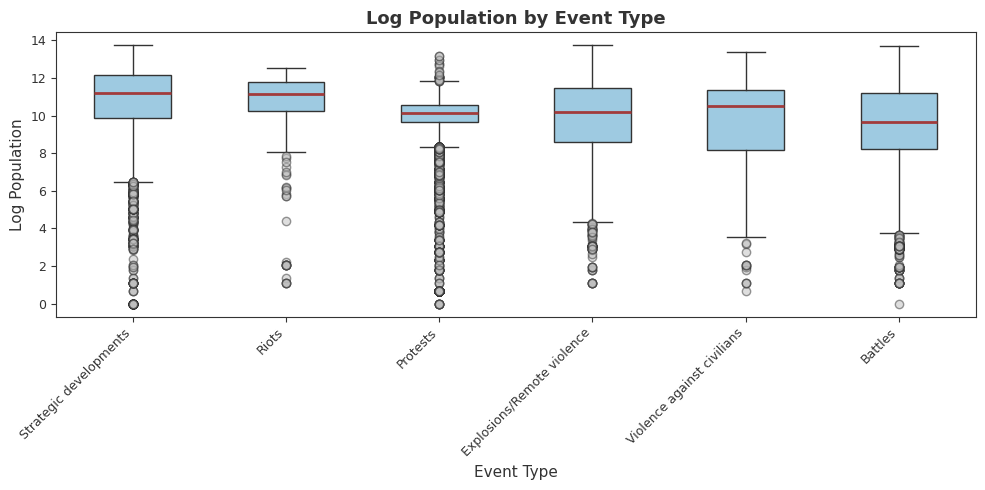


Step 3 — Equal variance assumption check


,test,purpose,test_statistic,p_value
0,Levene test,Checks equal variance assumption,337.896,<0.001



Step 4 — ANOVA tests


,test,assumption,test_statistic,p_value
0,Standard one-way ANOVA,Assumes equal variances,165.139,<0.001
1,Welch ANOVA,Does not assume equal variances,114.833,<0.001



Step 4.5 — Sensitivity check excluding zero population values

Descriptive summary after excluding log_population = 0:


...


Sensitivity check result:


,analysis,n,welch_statistic,p_value
0,Original RQ4 analysis,22110,114.833,<0.001
1,After excluding log_population = 0,22047,167.085,<0.001


Sensitivity check conclusion: The result remains statistically significant after excluding log_population = 0.

Step 5 — Pairwise comparisons with Holm correction


,group_1,group_2,mean_difference,t_statistic,raw_p_value,holm_p_value,significant_after_holm
3,Battles,Strategic developments,-1.357,-22.047,<0.001,<0.001,True
10,Protests,Strategic developments,-0.835,-19.575,<0.001,<0.001,True
7,Explosions/Remote violence,Strategic developments,-0.904,-10.886,<0.001,<0.001,True
1,Battles,Protests,-0.522,-10.581,<0.001,<0.001,True
14,Strategic developments,Violence against civilians,0.927,9.249,<0.001,<0.001,True
2,Battles,Riots,-1.252,-8.255,<0.001,<0.001,True
0,Battles,Explosions/Remote violence,-0.454,-5.235,<0.001,<0.001,True
9,Protests,Riots,-0.730,-5.032,<0.001,<0.001,True
6,Explosions/Remote violence,Riots,-0.798,-4.941,<0.001,<0.001,True
13,Riots,Violence against civilians,0.821,4.803,<0.001,<0.001,True



Step 6 — Decision summary
Levene's test is significant, so the equal variance assumption is not reasonable.
Welch's ANOVA is preferred for the final decision.
Decision: Reject H0.
Interpretation: Mean log population differs significantly across event types.


In [41]:
# ANALYSIS CELL 04 — RQ4: Population Context of Event Types

print("=== RQ4: POPULATION CONTEXT OF EVENT TYPES ===")
    
alpha = 0.05

# Research question:
# Do event types differ in their population context?

# log_population is used as the numerical response variable.
# event_type is used as the categorical grouping variable.
rq4_data = df_analysis[["event_type", "log_population"]].dropna().copy()

rq4_data["log_population"] = pd.to_numeric(
    rq4_data["log_population"],
    errors="coerce"
)

rq4_data = rq4_data.dropna(subset=["event_type", "log_population"]).copy()

# Keep only event types with enough observations.
# Very small groups may make ANOVA and pairwise comparisons unstable.
group_counts = rq4_data["event_type"].value_counts()
valid_event_types = group_counts[group_counts >= 10].index

rq4_data = rq4_data[
    rq4_data["event_type"].isin(valid_event_types)
].copy()

print("\nResearch Question 4:")
print("Do event types differ in their population context?")


# ---------------------------------------------------------
# Step 1 — Descriptive summary
# ---------------------------------------------------------

print("\nStep 1 — Descriptive summary of log population by event type")

population_context_summary = (
    rq4_data
    .groupby("event_type", observed=True)
    .agg(
        n=("log_population", "count"),
        mean_log_population=("log_population", "mean"),
        median_log_population=("log_population", "median"),
        std_log_population=("log_population", "std"),
        min_log_population=("log_population", "min"),
        max_log_population=("log_population", "max")
    )
    .sort_values("mean_log_population", ascending=False)
    .round(3)
)

display(population_context_summary)


# ---------------------------------------------------------
# Step 2 — Visual comparison
# ---------------------------------------------------------

print("\nStep 2 — Visual comparison")

boxplot_order = population_context_summary.index.tolist()

boxplot_groups = [
    rq4_data.loc[
        rq4_data["event_type"] == event_type,
        "log_population"
    ].values
    for event_type in boxplot_order
]

fig, ax = plt.subplots(figsize=(10, 5))

box = ax.boxplot(
    boxplot_groups,
    tick_labels=boxplot_order,
    patch_artist=True
)

for patch in box["boxes"]:
    patch.set_facecolor(SECONDARY)
    patch.set_edgecolor(DARK)

for median in box["medians"]:
    median.set_color(ACCENT)
    median.set_linewidth(2)

for whisker in box["whiskers"]:
    whisker.set_color(DARK)

for cap in box["caps"]:
    cap.set_color(DARK)

for flier in box["fliers"]:
    flier.set_markerfacecolor(NEUTRAL)
    flier.set_markeredgecolor(DARK)
    flier.set_alpha(0.5)

ax.set_title("Log Population by Event Type")
ax.set_xlabel("Event Type")
ax.set_ylabel("Log Population")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Step 3 — Assumption check
# ---------------------------------------------------------

print("\nStep 3 — Equal variance assumption check")

# Prepare group arrays for Levene's test and ANOVA.
grouped = list(rq4_data.groupby("event_type", observed=True))
group_names = [name for name, group in grouped]
groups = [group["log_population"].values for name, group in grouped]

# Levene's test checks whether the equal variance assumption is reasonable.
# H0: variances are equal across event types.
# HA: at least one variance is different.
levene_stat, levene_p = stats.levene(*groups, center="median")

variance_check = pd.DataFrame({
    "test": ["Levene test"],
    "purpose": ["Checks equal variance assumption"],
    "test_statistic": [levene_stat],
    "p_value": [format_p_value(levene_p)]
})

variance_check["test_statistic"] = (
    variance_check["test_statistic"]
    .round(3)
)

display(variance_check)


# ---------------------------------------------------------
# Step 4 — ANOVA tests
# ---------------------------------------------------------

print("\nStep 4 — ANOVA tests")

# Standard one-way ANOVA assumes equal variances.
standard_f_stat, standard_anova_p = stats.f_oneway(*groups)

# Welch's ANOVA does not assume equal variances.
welch_result = anova_oneway(
    rq4_data["log_population"],
    groups=rq4_data["event_type"],
    use_var="unequal"
)

anova_results = pd.DataFrame({
    "test": [
        "Standard one-way ANOVA",
        "Welch ANOVA"
    ],
    "assumption": [
        "Assumes equal variances",
        "Does not assume equal variances"
    ],
    "test_statistic": [
        standard_f_stat,
        welch_result.statistic
    ],
    "p_value": [
        format_p_value(standard_anova_p),
        format_p_value(welch_result.pvalue)
    ]
})

anova_results["test_statistic"] = (
    anova_results["test_statistic"]
    .round(3)
)

display(anova_results)

# ---------------------------------------------------------
# Step 4.5 — Sensitivity check for zero population values
# ---------------------------------------------------------

print("\nStep 4.5 — Sensitivity check excluding zero population values")

# Some observations have log_population equal to 0.
# This means the population proxy used for analysis is 0 for those events.
# To check whether these values affect the ANOVA result, we repeat Welch's ANOVA
# after excluding observations with log_population = 0.

rq4_sensitivity_data = rq4_data[rq4_data["log_population"] > 0].copy()

# Keep only event types with enough observations after excluding zero values.
sensitivity_group_counts = rq4_sensitivity_data["event_type"].value_counts()
valid_sensitivity_event_types = sensitivity_group_counts[
    sensitivity_group_counts >= 10
].index

rq4_sensitivity_data = rq4_sensitivity_data[
    rq4_sensitivity_data["event_type"].isin(valid_sensitivity_event_types)
].copy()

# Descriptive check for the sensitivity dataset.
sensitivity_summary = (
    rq4_sensitivity_data
    .groupby("event_type", observed=True)
    .agg(
        n=("log_population", "count"),
        mean_log_population=("log_population", "mean"),
        median_log_population=("log_population", "median"),
        std_log_population=("log_population", "std")
    )
    .sort_values("mean_log_population", ascending=False)
    .round(3)
)

print("\nDescriptive summary after excluding log_population = 0:")
display(sensitivity_summary)

# Repeat Welch's ANOVA on the sensitivity dataset.
welch_sensitivity_result = anova_oneway(
    rq4_sensitivity_data["log_population"],
    groups=rq4_sensitivity_data["event_type"],
    use_var="unequal"
)

# Compare original Welch ANOVA result with the sensitivity result.
sensitivity_result_table = pd.DataFrame({
    "analysis": [
        "Original RQ4 analysis",
        "After excluding log_population = 0"
    ],
    "n": [
        rq4_data.shape[0],
        rq4_sensitivity_data.shape[0]
    ],
    "welch_statistic": [
        welch_result.statistic,
        welch_sensitivity_result.statistic
    ],
    "p_value": [
        format_p_value(welch_result.pvalue),
        format_p_value(welch_sensitivity_result.pvalue)
    ]
})

sensitivity_result_table["welch_statistic"] = (
    sensitivity_result_table["welch_statistic"]
    .round(3)
)

print("\nSensitivity check result:")
display(sensitivity_result_table)

if welch_sensitivity_result.pvalue < alpha:
    print("Sensitivity check conclusion: The result remains statistically significant after excluding log_population = 0.")
else:
    print("Sensitivity check conclusion: The result is no longer statistically significant after excluding log_population = 0.")

# ---------------------------------------------------------
# Step 5 — Multiple comparisons
# ---------------------------------------------------------

print("\nStep 5 — Pairwise comparisons with Holm correction")

# ANOVA tells us whether at least one mean is different.
# Pairwise comparisons help identify which event type pairs differ.
# Welch pairwise t-tests are used because group variances may not be equal.
pairwise_results = []

for g1, g2 in combinations(group_names, 2):
    sample1 = rq4_data.loc[rq4_data["event_type"] == g1, "log_population"]
    sample2 = rq4_data.loc[rq4_data["event_type"] == g2, "log_population"]
    
    t_stat, raw_p = stats.ttest_ind(
        sample1,
        sample2,
        equal_var=False
    )
    
    pairwise_results.append({
        "group_1": g1,
        "group_2": g2,
        "mean_difference": sample1.mean() - sample2.mean(),
        "t_statistic": t_stat,
        "raw_p_value": raw_p
    })

pairwise_table = pd.DataFrame(pairwise_results)

reject, corrected_p_values, _, _ = multipletests(
    pairwise_table["raw_p_value"],
    alpha=alpha,
    method="holm"
)

pairwise_table["holm_p_value"] = corrected_p_values
pairwise_table["significant_after_holm"] = reject

# Keep raw numeric p-values for sorting, but add formatted columns for display.
pairwise_table["raw_p_value_display"] = (
    pairwise_table["raw_p_value"]
    .apply(format_p_value)
)

pairwise_table["holm_p_value_display"] = (
    pairwise_table["holm_p_value"]
    .apply(format_p_value)
)

pairwise_table = (
    pairwise_table
    .sort_values("holm_p_value")
)

# Create a clean display table.
pairwise_display_table = pairwise_table[
    [
        "group_1",
        "group_2",
        "mean_difference",
        "t_statistic",
        "raw_p_value_display",
        "holm_p_value_display",
        "significant_after_holm"
    ]
].copy()

pairwise_display_table = pairwise_display_table.rename(
    columns={
        "raw_p_value_display": "raw_p_value",
        "holm_p_value_display": "holm_p_value"
    }
)

pairwise_display_table[
    [
        "mean_difference",
        "t_statistic"
    ]
] = pairwise_display_table[
    [
        "mean_difference",
        "t_statistic"
    ]
].round(3)

display(pairwise_display_table)


# ---------------------------------------------------------
# Step 6 — Decision summary
# ---------------------------------------------------------

print("\nStep 6 — Decision summary")

if levene_p < alpha:
    print("Levene's test is significant, so the equal variance assumption is not reasonable.")
    print("Welch's ANOVA is preferred for the final decision.")
    final_p_value = welch_result.pvalue
else:
    print("Levene's test is not significant, so the equal variance assumption is reasonable.")
    print("Standard one-way ANOVA can be used for the final decision.")
    final_p_value = standard_anova_p

if final_p_value < alpha:
    print("Decision: Reject H0.")
    print("Interpretation: Mean log population differs significantly across event types.")
else:
    print("Decision: Do not reject H0.")
    print("Interpretation: There is not enough evidence that mean log population differs across event types.")

## RQ5 — Regression Model for Event Severity

This research question examines which variables are associated with event severity.

**Research Question 5:**  
Which variables are associated with event severity among recorded events?

The response variable is `log_fatalities`, defined as:

`log_fatalities = log(1 + fatalities)`

This transformation is used because the original `fatalities` variable is highly skewed and contains many zero values. However, even after the transformation, the response variable remains zero-heavy. Therefore, the regression models are interpreted as exploratory association models rather than perfect predictive or causal models.

Two regression models are considered:

1. **Simple linear regression:**  
   `log_fatalities` is modeled using only `violent_event`.

2. **Multiple linear regression:**  
   `log_fatalities` is modeled using `violent_event`, `actor_count`, `source_count`, and `log_population`.

The regression models are interpreted as association models, not causal models, because the dataset is observational.

The main assumptions checked are:

- linearity
- constant variance of residuals
- approximate normality of residuals
- multicollinearity among explanatory variables

The residual-based assumptions are checked after fitting the regression models because residuals are obtained from the fitted models. If the constant variance assumption is not reasonable, robust standard errors are used for coefficient inference.

=== RQ5: REGRESSION MODEL FOR EVENT SEVERITY ===

Research Question 5:
Which variables are associated with event severity?

Step 1 — Regression data summary


,count,mean,median,std,min,max
log_fatalities,22110.000,0.121,0.000,0.407,0.000,4.654
violent_event,22110.000,0.232,0.000,0.422,0.000,1.000
actor_count,22110.000,1.462,1.000,0.499,1.000,2.000
source_count,22110.000,1.313,1.000,0.677,1.000,9.000
log_population,22110.000,9.749,10.184,2.152,0.000,13.734



Step 2 — Fit regression models


,model,response_variable,predictors,purpose,standard_errors
0,Simple regression model,log_fatalities,violent_event,Checks the association between violent event c...,HC3 robust standard errors
1,Multiple regression model,log_fatalities,"violent_event, actor_count, source_count, log_...",Checks the association between several event/c...,HC3 robust standard errors



Step 3 — Regression coefficient tables

Simple regression results:


...

,test,purpose,test_statistic,p_value
0,Breusch-Pagan test,Checks constant variance of residuals,3783.589,<0.001


,test,purpose,test_statistic,p_value,skewness,kurtosis
0,Jarque-Bera test,Checks residual normality,283482.144,<0.001,2.776,19.640



Step 6 — Multicollinearity check


,variable,VIF
1,violent_event,1.408
2,actor_count,1.396
3,source_count,1.011
4,log_population,1.019



Step 7 — Diagnostic plots


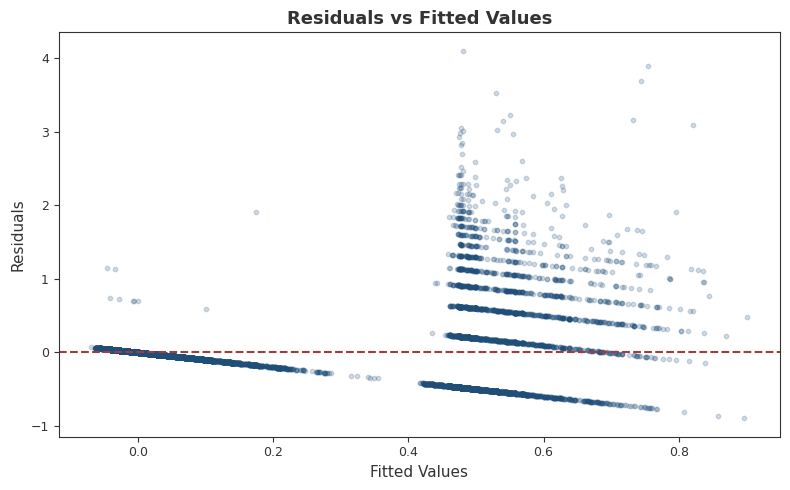

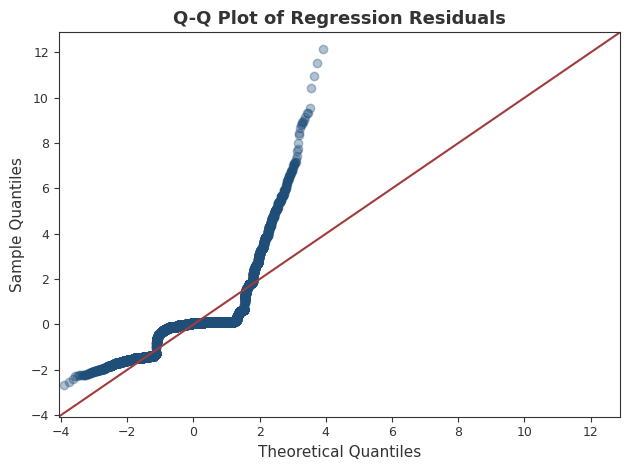


Step 8 — Interpretation summary
The regression models are interpreted as exploratory association models, not causal models.
The response variable is log(1 + fatalities), but it remains zero-heavy because many events have zero reported fatalities.
The Breusch-Pagan test is significant, so the constant variance assumption is not fully reasonable.
HC3 robust standard errors are used to make coefficient inference less sensitive to heteroskedasticity.
The Jarque-Bera test is significant, so residual normality is not fully satisfied.
Because the sample size is large, coefficient estimates are still interpreted cautiously, especially with robust standard errors.
The VIF values are used to check multicollinearity among predictors.
The OLS overall F-test is shown as a model-fit reference, while coefficient inference is based on HC3 robust standard errors.
Positive coefficients indicate higher expected log reported fatalities, holding the other variables constant.
Because some regression assump

In [42]:
# ANALYSIS CELL 05 — RQ5: Regression Model for Event Severity

print("=== RQ5: REGRESSION MODEL FOR EVENT SEVERITY ===")

alpha = 0.05

# Research question:
# Which variables are associated with event severity?

# log_fatalities is used as the response variable.
# This transformation reduces the extreme skewness of fatalities.
if "log_fatalities" not in df_analysis.columns:
    df_analysis["log_fatalities"] = np.log1p(df_analysis["fatalities"])

regression_vars = [
    "fatalities",
    "log_fatalities",
    "violent_event",
    "actor_count",
    "source_count",
    "log_population"
]

regression_vars = [
    col for col in regression_vars
    if col in df_analysis.columns
]

rq5_data = df_analysis[regression_vars].dropna().copy()

# Make sure all variables are numeric.
for col in regression_vars:
    rq5_data[col] = pd.to_numeric(rq5_data[col], errors="coerce")

rq5_data = rq5_data.dropna().copy()

print("\nResearch Question 5:")
print("Which variables are associated with event severity?")


# ---------------------------------------------------------
# Step 1 — Regression data summary
# ---------------------------------------------------------

print("\nStep 1 — Regression data summary")

regression_summary = (
    rq5_data[
        [
            "log_fatalities",
            "violent_event",
            "actor_count",
            "source_count",
            "log_population"
        ]
    ]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .T
    .round(3)
)

display(regression_summary)


# ---------------------------------------------------------
# Step 2 — Fit simple and multiple regression models
# ---------------------------------------------------------

print("\nStep 2 — Fit regression models")

# Simple model:
# This model checks the association between violent_event and event severity.
simple_model = smf.ols(
    "log_fatalities ~ violent_event",
    data=rq5_data
).fit()

# Multiple model:
# This model checks the association between several event/context variables and event severity.
multiple_model = smf.ols(
    "log_fatalities ~ violent_event + actor_count + source_count + log_population",
    data=rq5_data
).fit()

# Robust standard errors are used because event-level severity data may have unequal residual variance.
simple_model_robust = simple_model.get_robustcov_results(cov_type="HC3")
multiple_model_robust = multiple_model.get_robustcov_results(cov_type="HC3")

# Show model specifications so that this step is visible in the notebook output.
model_specification_table = pd.DataFrame({
    "model": [
        "Simple regression model",
        "Multiple regression model"
    ],
    "response_variable": [
        "log_fatalities",
        "log_fatalities"
    ],
    "predictors": [
        "violent_event",
        "violent_event, actor_count, source_count, log_population"
    ],
    "purpose": [
        "Checks the association between violent event classification and event severity",
        "Checks the association between several event/context variables and event severity"
    ],
    "standard_errors": [
        "HC3 robust standard errors",
        "HC3 robust standard errors"
    ]
})

display(model_specification_table)


# ---------------------------------------------------------
# Step 3 — Clean coefficient tables
# ---------------------------------------------------------

print("\nStep 3 — Regression coefficient tables")

def make_regression_table(model, robust_model):
    # This function creates a clean coefficient table using robust standard errors.
    conf_int = robust_model.conf_int()
    
    table = pd.DataFrame({
        "variable": model.params.index,
        "coefficient": robust_model.params,
        "robust_std_error": robust_model.bse,
        "t_statistic": robust_model.tvalues,
        "p_value_raw": robust_model.pvalues,
        "ci_lower_95": conf_int[:, 0],
        "ci_upper_95": conf_int[:, 1]
    })
    
    # Format p-values separately so very small values do not appear as 0.000.
    table["p_value"] = table["p_value_raw"].apply(format_p_value)
    
    table = table[
        [
            "variable",
            "coefficient",
            "robust_std_error",
            "t_statistic",
            "p_value",
            "ci_lower_95",
            "ci_upper_95"
        ]
    ]
    
    numeric_cols = [
        "coefficient",
        "robust_std_error",
        "t_statistic",
        "ci_lower_95",
        "ci_upper_95"
    ]
    
    table[numeric_cols] = table[numeric_cols].round(3)
    
    return table

simple_regression_table = make_regression_table(
    simple_model,
    simple_model_robust
)

multiple_regression_table = make_regression_table(
    multiple_model,
    multiple_model_robust
)

print("\nSimple regression results:")
display(simple_regression_table)

print("\nMultiple regression results:")
display(multiple_regression_table)


# ---------------------------------------------------------
# Step 4 — Model fit comparison
# ---------------------------------------------------------

print("\nStep 4 — Model fit comparison")

model_fit_table = pd.DataFrame({
    "model": [
        "Simple model",
        "Multiple model"
    ],
    "response_variable": [
        "log_fatalities",
        "log_fatalities"
    ],
    "predictors": [
        "violent_event",
        "violent_event, actor_count, source_count, log_population"
    ],
    "r_squared": [
        simple_model.rsquared,
        multiple_model.rsquared
    ],
    "adjusted_r_squared": [
        simple_model.rsquared_adj,
        multiple_model.rsquared_adj
    ],
    "AIC": [
        simple_model.aic,
        multiple_model.aic
    ],
    "BIC": [
        simple_model.bic,
        multiple_model.bic
    ]
}).round(3)

display(model_fit_table)


# ---------------------------------------------------------
# Step 4.5 — Overall model significance from OLS fit
# ---------------------------------------------------------

print("\nStep 4.5 — Overall model significance from OLS fit")

# The overall F-test checks whether at least one predictor is linearly associated with the response variable in the fitted OLS regression model.
# H0: all slope coefficients are equal to 0.
# HA: at least one slope coefficient is different from 0.
#
# Note:
# The coefficient tables use HC3 robust standard errors because heteroskedasticity is present. 
# The F-test below is shown as an OLS model-fit reference.
# Final coefficient inference is based on the robust standard errors.

overall_model_test_table = pd.DataFrame({
    "model": [
        "Simple model",
        "Multiple model"
    ],
    "F_statistic_OLS": [
        simple_model.fvalue,
        multiple_model.fvalue
    ],
    "F_p_value": [
        format_p_value(simple_model.f_pvalue),
        format_p_value(multiple_model.f_pvalue)
    ],
    "note": [
        "OLS model-fit reference; robust SE used for coefficient inference",
        "OLS model-fit reference; robust SE used for coefficient inference"
    ]
})

overall_model_test_table["F_statistic_OLS"] = (
    overall_model_test_table["F_statistic_OLS"]
    .round(3)
)

display(overall_model_test_table)


# ---------------------------------------------------------
# Step 5 — Regression assumption checks
# ---------------------------------------------------------

print("\nStep 5 — Regression assumption checks for the multiple model")

# We check assumptions mainly for the multiple model because it is the final association model.
fitted_values = multiple_model.fittedvalues
residuals = multiple_model.resid

# Breusch-Pagan test checks constant residual variance.
# H0: residual variance is constant.
# HA: residual variance is not constant.
bp_test = het_breuschpagan(
    residuals,
    multiple_model.model.exog
)

bp_results = pd.DataFrame({
    "test": ["Breusch-Pagan test"],
    "purpose": ["Checks constant variance of residuals"],
    "test_statistic": [bp_test[0]],
    "p_value_raw": [bp_test[1]]
})

bp_results["p_value"] = bp_results["p_value_raw"].apply(format_p_value)

bp_results = bp_results[
    [
        "test",
        "purpose",
        "test_statistic",
        "p_value"
    ]
]

bp_results["test_statistic"] = bp_results["test_statistic"].round(3)

display(bp_results)

# Jarque-Bera test checks residual normality.
# With large datasets, this test is very sensitive, so we also use the Q-Q plot below.
jb_stat, jb_p, skewness, kurtosis = jarque_bera(residuals)

normality_results = pd.DataFrame({
    "test": ["Jarque-Bera test"],
    "purpose": ["Checks residual normality"],
    "test_statistic": [jb_stat],
    "p_value_raw": [jb_p],
    "skewness": [skewness],
    "kurtosis": [kurtosis]
})

normality_results["p_value"] = (
    normality_results["p_value_raw"]
    .apply(format_p_value)
)

normality_results = normality_results[
    [
        "test",
        "purpose",
        "test_statistic",
        "p_value",
        "skewness",
        "kurtosis"
    ]
]

normality_results[
    [
        "test_statistic",
        "skewness",
        "kurtosis"
    ]
] = normality_results[
    [
        "test_statistic",
        "skewness",
        "kurtosis"
    ]
].round(3)

display(normality_results)

# ---------------------------------------------------------
# Step 6 — Multicollinearity check
# ---------------------------------------------------------

print("\nStep 6 — Multicollinearity check")

# VIF values are used to check whether explanatory variables are strongly related to each other.
# In practice, VIF values above 5 or 10 may indicate a multicollinearity problem.
# The constant term is included for calculation but removed from the displayed table because VIF for the intercept is not interpreted.

vif_variables = rq5_data[
    [
        "violent_event",
        "actor_count",
        "source_count",
        "log_population"
    ]
].copy()

vif_variables_with_constant = sm.add_constant(vif_variables)

vif_table = pd.DataFrame({
    "variable": vif_variables_with_constant.columns,
    "VIF": [
        variance_inflation_factor(vif_variables_with_constant.values, i)
        for i in range(vif_variables_with_constant.shape[1])
    ]
})

# Remove the constant row from the displayed VIF table.
vif_table = vif_table[vif_table["variable"] != "const"].copy()

vif_table["VIF"] = vif_table["VIF"].round(3)

display(vif_table)


# ---------------------------------------------------------
# Step 7 — Diagnostic plots
# ---------------------------------------------------------

print("\nStep 7 — Diagnostic plots")

# Residuals vs fitted values:
# This plot helps us visually check whether residual spread changes with fitted values.
plt.figure(figsize=(8, 5))

plt.scatter(
    fitted_values,
    residuals,
    alpha=0.20,
    s=10,
    color=PRIMARY
)

plt.axhline(
    0,
    linestyle="--",
    color=ACCENT,
    linewidth=1.5
)

plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()


# Q-Q plot:
# This plot helps us visually check whether residuals are approximately normal.
fig = sm.qqplot(
    residuals,
    line="45",
    fit=True
)

ax = fig.axes[0]

if len(ax.get_lines()) >= 1:
    ax.get_lines()[0].set_markerfacecolor(PRIMARY)
    ax.get_lines()[0].set_markeredgecolor(PRIMARY)
    ax.get_lines()[0].set_alpha(0.35)

if len(ax.get_lines()) >= 2:
    ax.get_lines()[1].set_color(ACCENT)
    ax.get_lines()[1].set_linewidth(1.5)

plt.title("Q-Q Plot of Regression Residuals")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Step 8 — Decision and interpretation summary
# ---------------------------------------------------------

print("\nStep 8 — Interpretation summary")

print("The regression models are interpreted as exploratory association models, not causal models.")
print("The response variable is log(1 + fatalities), but it remains zero-heavy because many events have zero reported fatalities.")

if bp_test[1] < alpha:
    print("The Breusch-Pagan test is significant, so the constant variance assumption is not fully reasonable.")
    print("HC3 robust standard errors are used to make coefficient inference less sensitive to heteroskedasticity.")
else:
    print("The Breusch-Pagan test is not significant, so there is no strong evidence against constant residual variance.")

if jb_p < alpha:
    print("The Jarque-Bera test is significant, so residual normality is not fully satisfied.")
    print("Because the sample size is large, coefficient estimates are still interpreted cautiously, especially with robust standard errors.")
else:
    print("The Jarque-Bera test is not significant, so residual normality is reasonably supported.")

print("The VIF values are used to check multicollinearity among predictors.")
print("The OLS overall F-test is shown as a model-fit reference, while coefficient inference is based on HC3 robust standard errors.")
print("Positive coefficients indicate higher expected log reported fatalities, holding the other variables constant.")
print("Because some regression assumptions are not fully satisfied, the results should be treated as evidence of association rather than as a final causal or predictive model.")


## Summary of Research Questions and Statistical Methods

The statistical analysis was organized around the main research questions of the project rather than around statistical methods alone.

| Research Question | Main Variables | Statistical Method |
|---|---|---|
| RQ1: Are protests the majority of recorded events, and is fatality status associated with event type? | `event_type`, `fatal_event` | One-sample proportion z-test; chi-square test of independence; Cramér’s V |
| RQ2: Do violent and non-violent events differ in fatal event rate? | `violent_event`, `fatal_event` | Two-proportion z-test |
| RQ3: Are more severe events associated with broader reporting coverage? | `fatal_event`, `source_count` | Descriptive reporting coverage check; Welch two-sample t-test; Mann-Whitney U sensitivity check |
| RQ4: Do event types differ in their population context? | `event_type`, `log_population` | Welch ANOVA; pairwise comparisons with Holm correction; sensitivity check excluding zero population proxy values |
| RQ5: Which variables are associated with event severity among recorded events? | `log_fatalities`, `violent_event`, `actor_count`, `source_count`, `log_population` | Simple and multiple linear regression with HC3 robust standard errors |

Overall, the analyses examine event composition, fatality status, reporting coverage, population context, and event severity.

Because the dataset is observational, the results are interpreted as statistical associations rather than causal effects.